# 09 — Biểu đồ so sánh năng lực mô hình

**Mục đích:** Vẽ biểu đồ so sánh ≥5 mô hình phục vụ báo cáo / luận văn.

**Chạy ở đâu:** Notebook này **chạy local** (Windows/Mac/Linux) và **Colab** — không cần GPU, không train lại model.

**Nguyên tắc:** Mọi số liệu vẽ biểu đồ đọc từ file CSV/JSON trong `reports/tables/` — **không ghi cứng metric trong code**.

**Đầu vào bắt buộc (chạy Phase 7 trước):**
- `reports/tables/phase7_final_metrics.csv`
- `reports/tables/phase7_multiseed_summary.csv`
- `reports/tables/phase7_ablation_delta.csv`
- `reports/tables/phase7_target_audit.csv`
- `reports/tables/viz_comparison_models.csv` (danh sách model hiển thị)
- `reports/tables/viz_radar_metrics.csv` (trục radar)

**Đầu vào bổ sung (fallback khi model chưa có trong Phase 7):**
- `reports/tables/phase5_leaderboard.csv` — ví dụ `phase5_stacking_calibrated`

**Insight:** Mỗi biểu đồ có cell `[INSIGHT]` in kết luận tự động từ CSV (dạng command, copy được vào báo cáo).

**Đầu ra:**
- Biểu đồ **hiển thị ngay trong notebook** khi chạy từng cell
- Đồng thời lưu PNG vào `reports/figures/viz_comparison_*.png`

## Hướng dẫn chạy local (Windows)

1. Mở terminal tại thư mục dự án `Fake_reviews`.
2. Cài thư viện (một lần): `pip install pandas matplotlib numpy`
3. Mở Jupyter: `jupyter notebook notebooks/09_Bieu_Do_So_Sanh_Mo_Hinh.ipynb`
4. Chạy **Run All** (Cell → Run All).

Nếu project không nằm ở vị trí mặc định, đặt biến môi trường trước khi mở Jupyter:

```powershell
$env:FAKE_REVIEWS_PROJECT_ROOT = "C:\duong\dan\den\Fake_reviews"
```

In [14]:
# ### BƯỚC 1 — CÀI ĐẶT THƯ VIỆN (bỏ qua nếu đã cài)

import importlib
# import subprocess: chạy lệnh pip/cài package
import subprocess
# import sys: tham số Python runtime
import sys


# dam_bao_thu_vien: hàm xử lý dam bao thu vien
def dam_bao_thu_vien(ten_import: str, ten_pip: str | None = None) -> None:
    # """Cài package nếu chưa có — hỗ trợ chạy local lần đầu.""": thực thi lệnh Python
    """Cài package nếu chưa có — hỗ trợ chạy local lần đầu."""
    # try/except: khối xử lý ngoại lệ
    try:
        # importlib.import_module(ten_import): thực thi lệnh Python
        importlib.import_module(ten_import)
    # except: xử lý ngoại lệ — except ImportError:
    except ImportError:
        # goi = ...: gán giá trị cho biến goi
        goi = ten_pip or ten_import
        # print(f"[CÀI ĐẶT] pip install {goi} ..."): in thông tin ra console
        print(f"[CÀI ĐẶT] pip install {goi} ...")
        # subprocess.check_call([sys.executable, "-m", "pip", "install", goi]): thực thi lệnh Python
        subprocess.check_call([sys.executable, "-m", "pip", "install", goi])


# for: vòng lặp — for pkg in ["pandas", "matplotlib", "numpy"]:
for pkg in ["pandas", "matplotlib", "numpy"]:
    # dam_bao_thu_vien(pkg): thực thi lệnh Python
    dam_bao_thu_vien(pkg)

# import matplotlib.pyplot: vẽ biểu đồ
import matplotlib.pyplot as plt
# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path

# Hiển thị biểu đồ ngay trong notebook (Jupyter / VS Code / Colab)
%matplotlib inline
# plt.rcParams["figure.dpi"] = 110: thực thi lệnh Python
plt.rcParams["figure.dpi"] = 110
# plt.rcParams["savefig.dpi"] = 160: thực thi lệnh Python
plt.rcParams["savefig.dpi"] = 160

# print("[OK] Thư viện sẵn sàng:", sys.version.split()[0]): in thông tin ra console
print("[OK] Thư viện sẵn sàng:", sys.version.split()[0])
# print("[OK] Chế độ vẽ: inline — biểu đồ hiện trực tiếp dưới mỗi cell"): in thông tin ra console
print("[OK] Chế độ vẽ: inline — biểu đồ hiện trực tiếp dưới mỗi cell")


[OK] Thư viện sẵn sàng: 3.10.8
[OK] Chế độ vẽ: inline — biểu đồ hiện trực tiếp dưới mỗi cell


In [15]:
# ### BƯỚC 2 — TÌM THƯ MỤC GỐC DỰ ÁN (local + Colab)

import os


# tim_thu_muc_goc: hàm xử lý tim thu muc goc
def tim_thu_muc_goc() -> Path:
    # """Tự nhận diện Fake_reviews từ cwd, thư mục notebooks/, hoặc biến môi trường.""...: thực thi lệnh Python
    """Tự nhận diện Fake_reviews từ cwd, thư mục notebooks/, hoặc biến môi trường."""
    # candidates: list[Path] = []: chuyển/chiếu thành list
    candidates: list[Path] = []
    # env_root = ...: ép kiểu chuỗi
    env_root = os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "").strip()
    # if: điều kiện — if env_root:
    if env_root:
        # candidates.append(Path(env_root)): thực thi lệnh Python
        candidates.append(Path(env_root))

    # cwd = ...: gán giá trị cho biến cwd
    cwd = Path.cwd().resolve()
    # candidates.extend([cwd, cwd.parent]): thực thi lệnh Python
    candidates.extend([cwd, cwd.parent])

    # candidates.extend([: thực thi lệnh Python
    candidates.extend([
        # Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),: thực thi lệnh Python
        Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),
        # Path("/content/drive/MyDrive/Fake_reviews"),: thực thi lệnh Python
        Path("/content/drive/MyDrive/Fake_reviews"),
    # ]): đóng list comprehension hoặc danh sách
    ])

    # for: vòng lặp — for path in candidates:
    for path in candidates:
        # if: điều kiện — if path.exists() and (path / "reports" / "tables" / "phase7_
        if path.exists() and (path / "reports" / "tables" / "phase7_final_metrics.csv").exists():
            # return: trả kết quả từ hàm
            return path

    # tried = ...: ép kiểu chuỗi
    tried = [str(p) for p in candidates if str(p)]
    # raise FileNotFoundError(: ném lỗi và dừng cell
    raise FileNotFoundError(
        # "Không tìm thấy Fake_reviews. Đặt FAKE_REVIEWS_PROJECT_ROOT hoặc cd vào thư mục ...: thực thi lệnh Python
        "Không tìm thấy Fake_reviews. Đặt FAKE_REVIEWS_PROJECT_ROOT hoặc cd vào thư mục dự án.\n"
        # f"Đã thử: {tried}": thực thi lệnh Python
        f"Đã thử: {tried}"
    # ): đóng ngoặc gọi hàm
    )


# PROJECT_ROOT: biến cấu hình/hằng số của notebook
PROJECT_ROOT = tim_thu_muc_goc()
# TABLE_DIR: biến cấu hình/hằng số của notebook
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
# FIGURE_DIR: biến cấu hình/hằng số của notebook
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
# FIGURE_DIR.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# print("[OK] Thư mục gốc dự án:", PROJECT_ROOT): in thông tin ra console
print("[OK] Thư mục gốc dự án:", PROJECT_ROOT)
# print("[OK] Bảng CSV:", TABLE_DIR): in thông tin ra console
print("[OK] Bảng CSV:", TABLE_DIR)
# print("[OK] Hình PNG sẽ lưu tại:", FIGURE_DIR): in thông tin ra console
print("[OK] Hình PNG sẽ lưu tại:", FIGURE_DIR)


[OK] Thư mục gốc dự án: C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews
[OK] Bảng CSV: C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\tables
[OK] Hình PNG sẽ lưu tại: C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures


In [16]:
# ### BƯỚC 3 — ĐỌC FILE CẤU HÌNH VÀ DỮ LIỆU (không hard-code số liệu)

DUONG_DAN_BAT_BUOC = {
    # "final_metrics": TABLE_DIR / "phase7_final_metrics.csv",: thực thi lệnh Python
    "final_metrics": TABLE_DIR / "phase7_final_metrics.csv",
    # "multiseed_summary": TABLE_DIR / "phase7_multiseed_summary.csv",: tính tổng
    "multiseed_summary": TABLE_DIR / "phase7_multiseed_summary.csv",
    # "ablation_delta": TABLE_DIR / "phase7_ablation_delta.csv",: thực thi lệnh Python
    "ablation_delta": TABLE_DIR / "phase7_ablation_delta.csv",
    # "target_audit": TABLE_DIR / "phase7_target_audit.csv",: thực thi lệnh Python
    "target_audit": TABLE_DIR / "phase7_target_audit.csv",
    # "model_config": TABLE_DIR / "viz_comparison_models.csv",: thực thi lệnh Python
    "model_config": TABLE_DIR / "viz_comparison_models.csv",
    # "radar_config": TABLE_DIR / "viz_radar_metrics.csv",: thực thi lệnh Python
    "radar_config": TABLE_DIR / "viz_radar_metrics.csv",
# }: đóng khối từ điển
}
# DUONG_DAN_BO_SUNG: biến cấu hình/hằng số của notebook
DUONG_DAN_BO_SUNG = {
    # "phase5_leaderboard": TABLE_DIR / "phase5_leaderboard.csv",: thực thi lệnh Python
    "phase5_leaderboard": TABLE_DIR / "phase5_leaderboard.csv",
    # "baseline_benchmark": TABLE_DIR / "baseline_benchmark_metrics.csv",: thực thi lệnh Python
    "baseline_benchmark": TABLE_DIR / "baseline_benchmark_metrics.csv",
# }: đóng khối từ điển
}

# for: vòng lặp — for ten, path in DUONG_DAN_BAT_BUOC.items():
for ten, path in DUONG_DAN_BAT_BUOC.items():
    # if: điều kiện — if not path.exists():
    if not path.exists():
        # raise FileNotFoundError(f"Thiếu file [{ten}]: {path}"): ném lỗi và dừng cell
        raise FileNotFoundError(f"Thiếu file [{ten}]: {path}")

# df_metrics = ...: đọc file CSV vào DataFrame
df_metrics = pd.read_csv(DUONG_DAN_BAT_BUOC["final_metrics"])
# df_multiseed = ...: đọc file CSV vào DataFrame
df_multiseed = pd.read_csv(DUONG_DAN_BAT_BUOC["multiseed_summary"])
# df_ablation = ...: đọc file CSV vào DataFrame
df_ablation = pd.read_csv(DUONG_DAN_BAT_BUOC["ablation_delta"])
# df_target = ...: đọc file CSV vào DataFrame
df_target = pd.read_csv(DUONG_DAN_BAT_BUOC["target_audit"])
# df_model_cfg = ...: đọc file CSV vào DataFrame
df_model_cfg = pd.read_csv(DUONG_DAN_BAT_BUOC["model_config"])
# df_radar_cfg = ...: đọc file CSV vào DataFrame
df_radar_cfg = pd.read_csv(DUONG_DAN_BAT_BUOC["radar_config"])

# df_phase5_lb = ...: gán giá trị cho biến df phase5 lb
df_phase5_lb = None
# df_baseline_benchmark = ...: gán giá trị cho biến df baseline benchmark
df_baseline_benchmark = None
# for: vòng lặp — for ten, path in DUONG_DAN_BO_SUNG.items():
for ten, path in DUONG_DAN_BO_SUNG.items():
    # if: điều kiện — if not path.exists():
    if not path.exists():
        # print(f"[CẢNH BÁO] Không có {path.name}"): in thông tin ra console
        print(f"[CẢNH BÁO] Không có {path.name}")
        continue
    # df_loaded = ...: đọc file CSV vào DataFrame
    df_loaded = pd.read_csv(path)
    # if: điều kiện — if ten == "phase5_leaderboard":
    if ten == "phase5_leaderboard":
        # df_phase5_lb = ...: gán giá trị cho biến df phase5 lb
        df_phase5_lb = df_loaded
        # print(f"[OK] Đã đọc {path.name}: {len(df_loaded)} dòng (fallback metric)"): in thông tin ra console
        print(f"[OK] Đã đọc {path.name}: {len(df_loaded)} dòng (fallback metric)")
    # elif: nhánh điều kiện phụ — elif ten == "baseline_benchmark":
    elif ten == "baseline_benchmark":
        # df_baseline_benchmark = ...: gán giá trị cho biến df baseline benchmark
        df_baseline_benchmark = df_loaded
        # print(f"[OK] Đã đọc {path.name}: {len(df_loaded)} dòng (Tier-1 benchmark)"): in thông tin ra console
        print(f"[OK] Đã đọc {path.name}: {len(df_loaded)} dòng (Tier-1 benchmark)")

# Tham số lọc — chỉ metadata, không phải kết quả metric
SEED = int(df_metrics["seed"].dropna().iloc[0])
# SPLIT: biến cấu hình/hằng số của notebook
SPLIT = "test"
# NGUONG_SO_SANH: biến cấu hình/hằng số của notebook
NGUONG_SO_SANH = 0.5  # τ mặc định khi so sánh nhiều model (đồng bộ Phase 7 default)

# print(f"[OK] Đã đọc phase7_final_metrics: {len(df_metrics)} dòng"): in thông tin ra console
print(f"[OK] Đã đọc phase7_final_metrics: {len(df_metrics)} dòng")
# print(f"[OK] Cấu hình hiển thị: {len(df_model_cfg)} model trong viz_comparison_m...: in thông tin ra console
print(f"[OK] Cấu hình hiển thị: {len(df_model_cfg)} model trong viz_comparison_models.csv")
# print(f"[OK] Seed={SEED}, split={SPLIT}, ngưỡng so sánh τ={NGUONG_SO_SANH}"): in thông tin ra console
print(f"[OK] Seed={SEED}, split={SPLIT}, ngưỡng so sánh τ={NGUONG_SO_SANH}")


[OK] Đã đọc phase5_leaderboard.csv: 12 dòng (fallback metric)
[OK] Đã đọc phase7_final_metrics: 36 dòng
[OK] Cấu hình hiển thị: 8 model trong viz_comparison_models.csv
[OK] Seed=42, split=test, ngưỡng so sánh τ=0.5


In [17]:
# ### BƯỚC 4 — HÀM TIỆN ÍCH: GHÉP TÊN HIỂN THỊ + LỌC METRIC


def loc_metric_test(df: pd.DataFrame, threshold: float = NGUONG_SO_SANH) -> pd.DataFrame:
    # """Lọc dòng test @ ngưỡng cho các model trong file cấu hình.""": xóa biến để giải phóng RAM/VRAM
    """Lọc dòng test @ ngưỡng cho các model trong file cấu hình."""
    # variants = ...: chuyển/chiếu thành list
    variants = df_model_cfg["model_variant"].tolist()
    # out = ...: gán giá trị cho biến out
    out = df[
        # (df["split"] == SPLIT): thực thi lệnh Python
        (df["split"] == SPLIT)
        # & (df["seed"] == SEED): thực thi lệnh Python
        & (df["seed"] == SEED)
        # & (df["model_variant"].isin(variants)): thực thi lệnh Python
        & (df["model_variant"].isin(variants))
        # & (df["threshold"].astype(float).round(2) == round(threshold, 2)): ép kiểu dữ liệu cột
        & (df["threshold"].astype(float).round(2) == round(threshold, 2))
    # ].copy(): thực thi lệnh Python
    ].copy()
    # out["nguon_du_lieu"] = "phase7_final_metrics": thực thi lệnh Python
    out["nguon_du_lieu"] = "phase7_final_metrics"
    # return: trả kết quả từ hàm
    return out


# ghep_metric_tu_nhieu_file: hàm xử lý ghep metric tu nhieu file
def ghep_metric_tu_nhieu_file(threshold: float = NGUONG_SO_SANH) -> pd.DataFrame:
    # """Ưu tiên baseline_benchmark (nb10), rồi Phase 7, rồi phase5_leaderboard.""": thực thi lệnh Python
    """Ưu tiên baseline_benchmark (nb10), rồi Phase 7, rồi phase5_leaderboard."""
    # variants = ...: chuyển/chiếu thành list
    variants = df_model_cfg["model_variant"].tolist()

    # if: điều kiện — if df_baseline_benchmark is not None:
    if df_baseline_benchmark is not None:
        # bb = ...: gán giá trị cho biến bb
        bb = df_baseline_benchmark[
            # (df_baseline_benchmark["split"] == SPLIT): thực thi lệnh Python
            (df_baseline_benchmark["split"] == SPLIT)
            # & (df_baseline_benchmark["seed"] == SEED): thực thi lệnh Python
            & (df_baseline_benchmark["seed"] == SEED)
            # & (df_baseline_benchmark["model_variant"].isin(variants)): thực thi lệnh Python
            & (df_baseline_benchmark["model_variant"].isin(variants))
            # & (df_baseline_benchmark["threshold"].astype(float).round(2) == round(threshold,...: ép kiểu dữ liệu cột
            & (df_baseline_benchmark["threshold"].astype(float).round(2) == round(threshold, 2))
        # ].copy(): thực thi lệnh Python
        ].copy()
        # if: điều kiện — if len(bb) == len(df_model_cfg):
        if len(bb) == len(df_model_cfg):
            # bb = ...: hiển thị bảng/kết quả trên notebook
            bb = bb.rename(columns={"display_name": "ten_hien_thi", "model_group": "nhom", "display_order": "thu_tu"})
            # bb["nguon_du_lieu"] = "baseline_benchmark_metrics": thực thi lệnh Python
            bb["nguon_du_lieu"] = "baseline_benchmark_metrics"
            # return: trả kết quả từ hàm
            return bb.sort_values("thu_tu")

    # out = ...: gán giá trị cho biến out
    out = loc_metric_test(df_metrics, threshold)
    # thieu = ...: sắp xếp danh sách
    thieu = sorted(set(variants) - set(out["model_variant"]))
    # if: điều kiện — if thieu and df_baseline_benchmark is not None:
    if thieu and df_baseline_benchmark is not None:
        # bo_sung_bb = ...: gán giá trị cho biến bo sung bb
        bo_sung_bb = df_baseline_benchmark[
            # (df_baseline_benchmark["split"] == SPLIT): thực thi lệnh Python
            (df_baseline_benchmark["split"] == SPLIT)
            # & (df_baseline_benchmark["seed"] == SEED): thực thi lệnh Python
            & (df_baseline_benchmark["seed"] == SEED)
            # & (df_baseline_benchmark["model_variant"].isin(thieu)): thực thi lệnh Python
            & (df_baseline_benchmark["model_variant"].isin(thieu))
            # & (df_baseline_benchmark["threshold"].astype(float).round(2) == round(threshold,...: ép kiểu dữ liệu cột
            & (df_baseline_benchmark["threshold"].astype(float).round(2) == round(threshold, 2))
        # ].copy(): thực thi lệnh Python
        ].copy()
        # if: điều kiện — if not bo_sung_bb.empty:
        if not bo_sung_bb.empty:
            # bo_sung_bb["nguon_du_lieu"] = "baseline_benchmark_metrics": thực thi lệnh Python
            bo_sung_bb["nguon_du_lieu"] = "baseline_benchmark_metrics"
            # out = ...: nối nhiều DataFrame
            out = pd.concat([out, bo_sung_bb], ignore_index=True)
            # thieu = ...: sắp xếp danh sách
            thieu = sorted(set(variants) - set(out["model_variant"]))
            # print(f"[BỔ SUNG] Lấy từ baseline_benchmark: {bo_sung_bb['model_variant'].tolist...: in thông tin ra console
            print(f"[BỔ SUNG] Lấy từ baseline_benchmark: {bo_sung_bb['model_variant'].tolist()}")

    # if: điều kiện — if thieu:
    if thieu:
        # if: điều kiện — if df_phase5_lb is None:
        if df_phase5_lb is None:
            # raise ValueError(: ném lỗi và dừng cell
            raise ValueError(
                # f"Thiếu metric cho {thieu} trong phase7/baseline và không có phase5_leaderboard....: thực thi lệnh Python
                f"Thiếu metric cho {thieu} trong phase7/baseline và không có phase5_leaderboard.csv."
            # ): đóng ngoặc gọi hàm
            )
        # bo_sung = ...: gán giá trị cho biến bo sung
        bo_sung = df_phase5_lb[
            # (df_phase5_lb["split"] == SPLIT): thực thi lệnh Python
            (df_phase5_lb["split"] == SPLIT)
            # & (df_phase5_lb["seed"] == SEED): thực thi lệnh Python
            & (df_phase5_lb["seed"] == SEED)
            # & (df_phase5_lb["model_variant"].isin(thieu)): thực thi lệnh Python
            & (df_phase5_lb["model_variant"].isin(thieu))
            # & (df_phase5_lb["threshold"].astype(float).round(2) == round(threshold, 2)): ép kiểu dữ liệu cột
            & (df_phase5_lb["threshold"].astype(float).round(2) == round(threshold, 2))
        # ].copy(): thực thi lệnh Python
        ].copy()
        # if: điều kiện — if bo_sung.empty:
        if bo_sung.empty:
            # raise ValueError(: ném lỗi và dừng cell
            raise ValueError(
                # f"Không tìm thấy dòng test τ={threshold} cho {thieu} trong phase5_leaderboard.cs...: thực thi lệnh Python
                f"Không tìm thấy dòng test τ={threshold} cho {thieu} trong phase5_leaderboard.csv."
            # ): đóng ngoặc gọi hàm
            )
        # bo_sung["nguon_du_lieu"] = "phase5_leaderboard": thực thi lệnh Python
        bo_sung["nguon_du_lieu"] = "phase5_leaderboard"
        # out = ...: nối nhiều DataFrame
        out = pd.concat([out, bo_sung], ignore_index=True)
        # print(f"[BỔ SUNG] Lấy từ phase5_leaderboard: {thieu}"): in thông tin ra console
        print(f"[BỔ SUNG] Lấy từ phase5_leaderboard: {thieu}")

    # if: điều kiện — if "ten_hien_thi" in out.columns:
    if "ten_hien_thi" in out.columns:
        # cfg_cols = ...: gán giá trị cho biến cfg cols
        cfg_cols = [c for c in ["model_variant", "ten_hien_thi", "nhom", "thu_tu", "highlight"] if c in out.columns or c in df_model_cfg.columns]
        # if: điều kiện — if set(cfg_cols) - set(out.columns):
        if set(cfg_cols) - set(out.columns):
            # out = ...: ghép hai DataFrame
            out = out.merge(df_model_cfg, on="model_variant", how="inner")
    # else: nhánh còn lại của điều kiện
    else:
        # out = ...: ghép hai DataFrame
        out = out.merge(df_model_cfg, on="model_variant", how="inner")
    # out = ...: gán giá trị cho biến out
    out = out.sort_values("thu_tu")
    # return: trả kết quả từ hàm
    return out


# ve_luu_va_hien_thi: hàm xử lý ve luu va hien thi
def ve_luu_va_hien_thi(fig: plt.Figure, ten_file: str) -> Path:
    # """Vẽ trong notebook + lưu PNG ra reports/figures/.""": thực thi lệnh Python
    """Vẽ trong notebook + lưu PNG ra reports/figures/."""
    # path = ...: gán giá trị cho biến path
    path = FIGURE_DIR / ten_file
    # fig.tight_layout(): thực thi lệnh Python
    fig.tight_layout()
    # fig.savefig(path, dpi=160, bbox_inches="tight"): thực thi lệnh Python
    fig.savefig(path, dpi=160, bbox_inches="tight")
    # plt.show(): hiển thị biểu đồ
    plt.show()  # hiển thị biểu đồ ngay dưới cell này
    # plt.close(fig): thực thi lệnh Python
    plt.close(fig)
    # print(f"[HIỂN THỊ] {ten_file}"): in thông tin ra console
    print(f"[HIỂN THỊ] {ten_file}")
    # print(f"[LƯU] {path}"): in thông tin ra console
    print(f"[LƯU] {path}")
    # return: trả kết quả từ hàm
    return path



# in_insight: hàm xử lý in insight
def in_insight(so: int, *dong: str) -> None:
    # """In insight dạng command — đọc từ CSV, không ghi cứng số.""": thực thi lệnh Python
    """In insight dạng command — đọc từ CSV, không ghi cứng số."""
    # for: vòng lặp — for i, d in enumerate(dong, 1):
    for i, d in enumerate(dong, 1):
        # print(f"[INSIGHT {so}.{i}] {d}"): in thông tin ra console
        print(f"[INSIGHT {so}.{i}] {d}")
    # print(): in thông tin ra console
    print()

# df_compare = ...: gán giá trị cho biến df compare
df_compare = ghep_metric_tu_nhieu_file()
# if: điều kiện — if len(df_compare) != len(df_model_cfg):
if len(df_compare) != len(df_model_cfg):
    # co = ...: tạo tập hợp
    co = set(df_compare["model_variant"])
    # thieu = ...: tạo tập hợp
    thieu = set(df_model_cfg["model_variant"]) - co
    # raise ValueError(: ném lỗi và dừng cell
    raise ValueError(
        # f"Chỉ khớp {len(df_compare)}/{len(df_model_cfg)} model. Thiếu: {sorted(thieu)}": sắp xếp danh sách
        f"Chỉ khớp {len(df_compare)}/{len(df_model_cfg)} model. Thiếu: {sorted(thieu)}"
    # ): đóng ngoặc gọi hàm
    )

# print("[OK] Bảng so sánh sau lọc:"): in thông tin ra console
print("[OK] Bảng so sánh sau lọc:")
# display_cols = ...: hiển thị bảng/kết quả trên notebook
display_cols = ["ten_hien_thi", "macro_f1", "precision_fake", "recall_fake", "roc_auc", "nguon_du_lieu"]
# print(df_compare[display_cols].to_string(index=False)): hiển thị bảng/kết quả trên notebook
print(df_compare[display_cols].to_string(index=False))


[BỔ SUNG] Lấy từ phase5_leaderboard: ['phase5_stacking_calibrated']
[OK] Bảng so sánh sau lọc:
            ten_hien_thi  macro_f1  precision_fake  recall_fake  roc_auc        nguon_du_lieu
       DL baseline (PCA)  0.766460        0.781827     0.645960 0.838937 phase7_final_metrics
       XGBoost raw 777-d  0.905938        0.968579     0.810595 0.953063 phase7_final_metrics
     Stacking calibrated  0.910491        0.972789     0.817454 0.973124   phase5_leaderboard
     CNN-BiLSTM sequence  0.934290        0.946500     0.896723 0.972582 phase7_final_metrics
Weighted blend (de xuat)  0.943320        0.969872     0.895579 0.976900 phase7_final_metrics
      LightGBM raw 777-d  0.905099        0.967654     0.809451 0.954835 phase7_final_metrics
           MLP raw 777-d  0.898961        0.916183     0.841463 0.950465 phase7_final_metrics
            DL-PSO (PCA)  0.779349        0.781866     0.680259 0.851668 phase7_final_metrics


## Biểu đồ 1 — Cột ngang: Macro F1 (xếp hạng model)

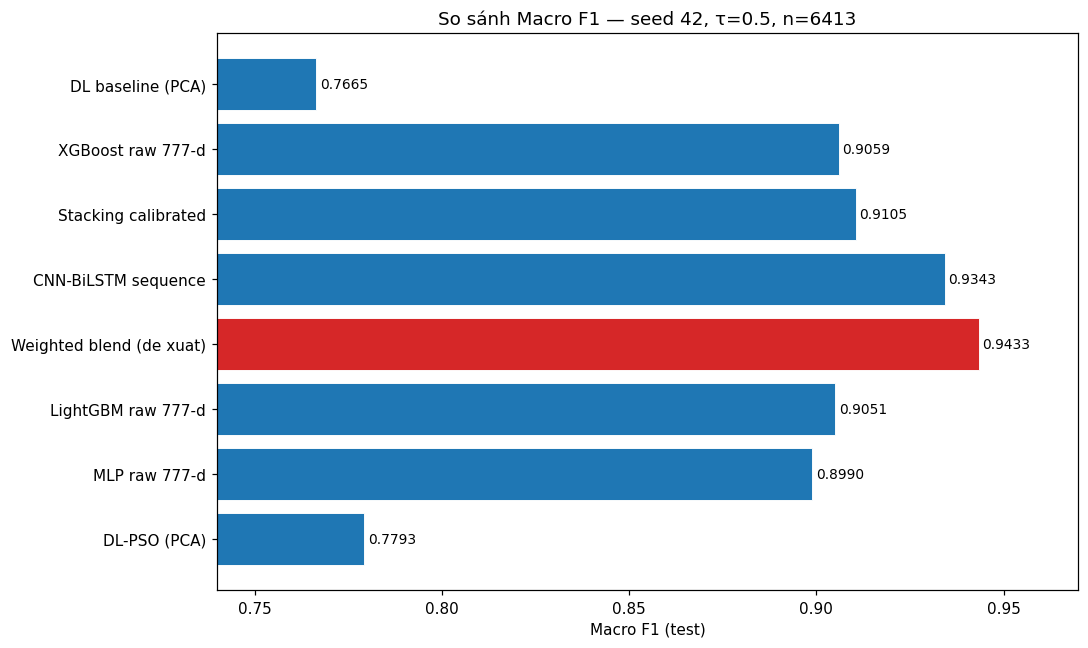

[HIỂN THỊ] viz_comparison_macro_f1_horizontal.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_macro_f1_horizontal.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_macro_f1_horizontal.png')

In [18]:
# ### VẼ BIỂU ĐỒ 1 — MACRO F1 (đọc từ df_compare)

labels = df_compare["ten_hien_thi"].tolist()
# values = ...: ép kiểu dữ liệu cột
values = df_compare["macro_f1"].astype(float).tolist()
# colors = ...: gán giá trị cho biến colors
colors = ["#d62728" if int(h) == 1 else "#1f77b4" for h in df_compare["highlight"]]

# fig, ax = plt.subplots(figsize=(10, 6)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(10, 6))
# y_pos = ...: tạo dãy số cho vòng lặp
y_pos = np.arange(len(labels))
# bars = ...: gán giá trị cho biến bars
bars = ax.barh(y_pos, values, color=colors, edgecolor="white", linewidth=0.6)
# ax.set_yticks(y_pos): tạo tập hợp
ax.set_yticks(y_pos)
# ax.set_yticklabels(labels): tạo tập hợp
ax.set_yticklabels(labels)
# ax.set_xlabel("Macro F1 (test)"): tạo tập hợp
ax.set_xlabel("Macro F1 (test)")
# ax.set_title(f"So sánh Macro F1 — seed {SEED}, τ={NGUONG_SO_SANH}, n={int(df_com...: tạo tập hợp
ax.set_title(f"So sánh Macro F1 — seed {SEED}, τ={NGUONG_SO_SANH}, n={int(df_compare['support_fake'].iloc[0] + df_compare['support_real'].iloc[0])}")
# ax.invert_yaxis(): thực thi lệnh Python
ax.invert_yaxis()

# x_min = ...: lấy giá trị nhỏ nhất
x_min = min(values)
# x_pad = ...: lấy giá trị nhỏ nhất
x_pad = max((max(values) - x_min) * 0.15, 0.01)
# ax.set_xlim(left=max(0.0, x_min - x_pad), right=max(values) + x_pad): tạo tập hợp
ax.set_xlim(left=max(0.0, x_min - x_pad), right=max(values) + x_pad)

# for: vòng lặp — for bar, val in zip(bars, values):
for bar, val in zip(bars, values):
    # ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{val:.4f}...: thực thi lệnh Python
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va="center", fontsize=9)

# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_macro_f1_horizontal.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_macro_f1_horizontal.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [19]:
# ### INSIGHT — Biểu đồ 1: Xếp hạng Macro F1 (tự tính từ df_compare)

best = df_compare.loc[df_compare["macro_f1"].astype(float).idxmax()]
# worst = ...: ép kiểu dữ liệu cột
worst = df_compare.loc[df_compare["macro_f1"].astype(float).idxmin()]
# de_xuat = ...: ép kiểu dữ liệu cột
de_xuat = df_compare[df_compare["highlight"].astype(int) == 1].iloc[0]
# top3 = ...: chuyển/chiếu thành list
top3 = df_compare.nlargest(3, "macro_f1")["ten_hien_thi"].tolist()
# gap = ...: ép kiểu số thực
gap = float(best["macro_f1"]) - float(worst["macro_f1"])

# in_insight(: thực thi lệnh Python
in_insight(
    # 1,: thực thi lệnh Python
    1,
    # f"Model cao nhất: {best['ten_hien_thi']} | Macro F1 = {float(best['macro_f1']):....: ép kiểu số thực
    f"Model cao nhất: {best['ten_hien_thi']} | Macro F1 = {float(best['macro_f1']):.4f} | nguồn: {best['nguon_du_lieu']}",
    # f"Model thấp nhất: {worst['ten_hien_thi']} | Macro F1 = {float(worst['macro_f1']...: ép kiểu số thực
    f"Model thấp nhất: {worst['ten_hien_thi']} | Macro F1 = {float(worst['macro_f1']):.4f}",
    # f"Top 3: {', '.join(top3)}",: thực thi lệnh Python
    f"Top 3: {', '.join(top3)}",
    # f"Khoảng cách best–worst = {gap:.4f} → mô hình DL đơn (PCA) kém ensemble tabular...: thực thi lệnh Python
    f"Khoảng cách best–worst = {gap:.4f} → mô hình DL đơn (PCA) kém ensemble tabular+sequence rõ rệt",
    # f"Mô hình đề xuất (highlight): {de_xuat['ten_hien_thi']} | Macro F1 = {float(de_...: ép kiểu số thực
    f"Mô hình đề xuất (highlight): {de_xuat['ten_hien_thi']} | Macro F1 = {float(de_xuat['macro_f1']):.4f}",
# ): đóng ngoặc gọi hàm
)


[INSIGHT 1.1] Model cao nhất: Weighted blend (de xuat) | Macro F1 = 0.9433 | nguồn: phase7_final_metrics
[INSIGHT 1.2] Model thấp nhất: DL baseline (PCA) | Macro F1 = 0.7665
[INSIGHT 1.3] Top 3: Weighted blend (de xuat), CNN-BiLSTM sequence, Stacking calibrated
[INSIGHT 1.4] Khoảng cách best–worst = 0.1769 → mô hình DL đơn (PCA) kém ensemble tabular+sequence rõ rệt
[INSIGHT 1.5] Mô hình đề xuất (highlight): Weighted blend (de xuat) | Macro F1 = 0.9433



## Biểu đồ 2 — Cột nhóm: Macro F1, Precision Fake, Recall Fake, ROC-AUC

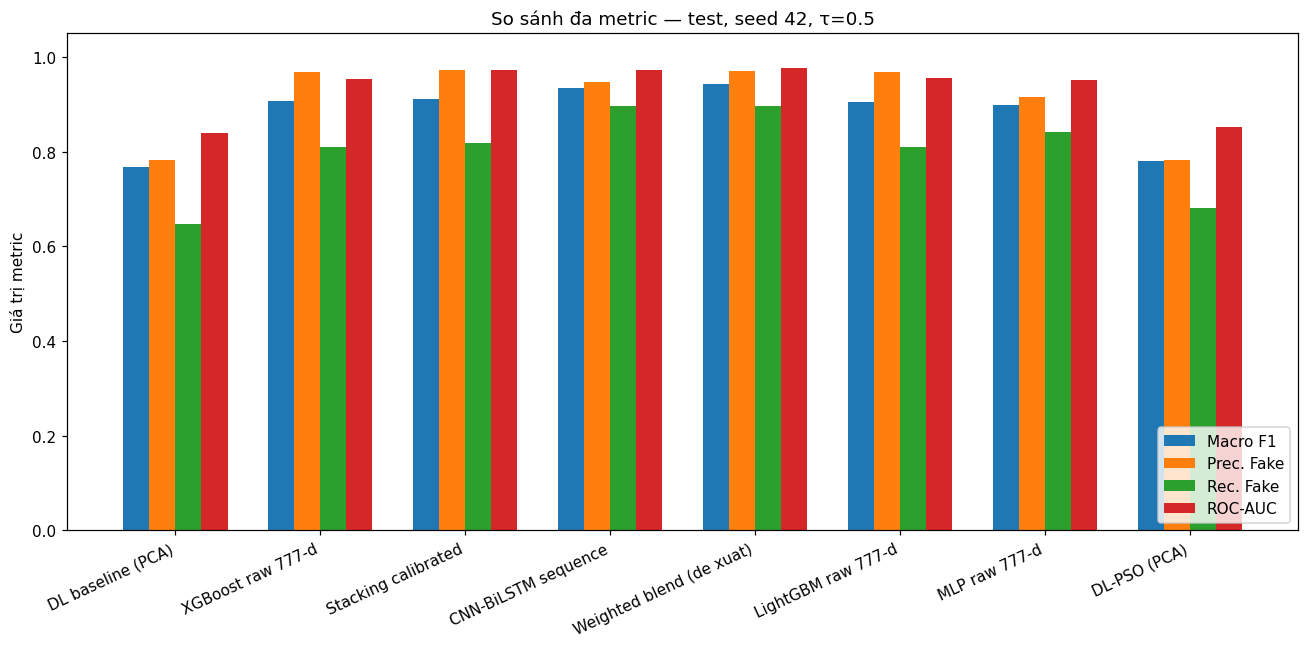

[HIỂN THỊ] viz_comparison_grouped_metrics.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_grouped_metrics.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_grouped_metrics.png')

In [20]:
# ### VẼ BIỂU ĐỒ 2 — GROUPED BAR (4 metric từ CSV)

metric_cols = ["macro_f1", "precision_fake", "recall_fake", "roc_auc"]
# metric_labels = ...: gán giá trị cho biến metric labels
metric_labels = ["Macro F1", "Prec. Fake", "Rec. Fake", "ROC-AUC"]

# x = ...: tạo dãy số cho vòng lặp
x = np.arange(len(df_compare))
# width = ...: gán giá trị cho biến width
width = 0.18
# fig, ax = plt.subplots(figsize=(12, 6)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(12, 6))

# for: vòng lặp — for i, (col, lab) in enumerate(zip(metric_cols, metric_label
for i, (col, lab) in enumerate(zip(metric_cols, metric_labels)):
    # vals = ...: ép kiểu dữ liệu cột
    vals = df_compare[col].astype(float).values
    # ax.bar(x + (i - 1.5) * width, vals, width, label=lab): thực thi lệnh Python
    ax.bar(x + (i - 1.5) * width, vals, width, label=lab)

# ax.set_xticks(x): tạo tập hợp
ax.set_xticks(x)
# ax.set_xticklabels(df_compare["ten_hien_thi"], rotation=25, ha="right"): tạo tập hợp
ax.set_xticklabels(df_compare["ten_hien_thi"], rotation=25, ha="right")
# ax.set_ylabel("Giá trị metric"): tạo tập hợp
ax.set_ylabel("Giá trị metric")
# ax.set_title(f"So sánh đa metric — test, seed {SEED}, τ={NGUONG_SO_SANH}"): tạo tập hợp
ax.set_title(f"So sánh đa metric — test, seed {SEED}, τ={NGUONG_SO_SANH}")
# ax.legend(loc="lower right"): thực thi lệnh Python
ax.legend(loc="lower right")
# ax.set_ylim(0, 1.05): tạo tập hợp
ax.set_ylim(0, 1.05)
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_grouped_metrics.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_grouped_metrics.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [21]:
# ### INSIGHT — Biểu đồ 2: So sánh đa metric

cols = ["macro_f1", "precision_fake", "recall_fake", "roc_auc"]
# labels = ...: gán giá trị cho biến labels
labels = {
    # "macro_f1": "Macro F1",: thực thi lệnh Python
    "macro_f1": "Macro F1",
    # "precision_fake": "Precision Fake",: thực thi lệnh Python
    "precision_fake": "Precision Fake",
    # "recall_fake": "Recall Fake",: thực thi lệnh Python
    "recall_fake": "Recall Fake",
    # "roc_auc": "ROC-AUC",: thực thi lệnh Python
    "roc_auc": "ROC-AUC",
# }: đóng khối từ điển
}
# dong = ...: gán giá trị cho biến dong
dong = []
# for: vòng lặp — for col in cols:
for col in cols:
    # row = ...: ép kiểu dữ liệu cột
    row = df_compare.loc[df_compare[col].astype(float).idxmax()]
    # dong.append(f"Cao nhất {labels[col]}: {row['ten_hien_thi']} = {float(row[col]):....: ép kiểu số thực
    dong.append(f"Cao nhất {labels[col]}: {row['ten_hien_thi']} = {float(row[col]):.4f}")
# blend = ...: đếm số phần tử
blend = df_compare[df_compare["model_variant"] == "phase5_weighted_blend"].iloc[0]
# dong.append(: thực thi lệnh Python
dong.append(
    # f"Weighted blend cân bằng cả 4 metric: Macro F1={float(blend['macro_f1']):.4f}, ...: ép kiểu số thực
    f"Weighted blend cân bằng cả 4 metric: Macro F1={float(blend['macro_f1']):.4f}, Prec={float(blend['precision_fake']):.4f}, Rec={float(blend['recall_fake']):.4f}, AUC={float(blend['roc_auc']):.4f}"
# ): đóng ngoặc gọi hàm
)
# dong.append("Không có model nào thắng tuyệt đối cả 4 trục → blend là lựa chọn tổ...: xóa biến để giải phóng RAM/VRAM
dong.append("Không có model nào thắng tuyệt đối cả 4 trục → blend là lựa chọn tổng hợp hợp lý cho production")
# in_insight(2, *dong): thực thi lệnh Python
in_insight(2, *dong)


[INSIGHT 2.1] Cao nhất Macro F1: Weighted blend (de xuat) = 0.9433
[INSIGHT 2.2] Cao nhất Precision Fake: Stacking calibrated = 0.9728
[INSIGHT 2.3] Cao nhất Recall Fake: CNN-BiLSTM sequence = 0.8967
[INSIGHT 2.4] Cao nhất ROC-AUC: Weighted blend (de xuat) = 0.9769
[INSIGHT 2.5] Weighted blend cân bằng cả 4 metric: Macro F1=0.9433, Prec=0.9699, Rec=0.8956, AUC=0.9769
[INSIGHT 2.6] Không có model nào thắng tuyệt đối cả 4 trục → blend là lựa chọn tổng hợp hợp lý cho production



## Biểu đồ 3 — Radar (chuẩn hóa min–max trên tập model đang so sánh)

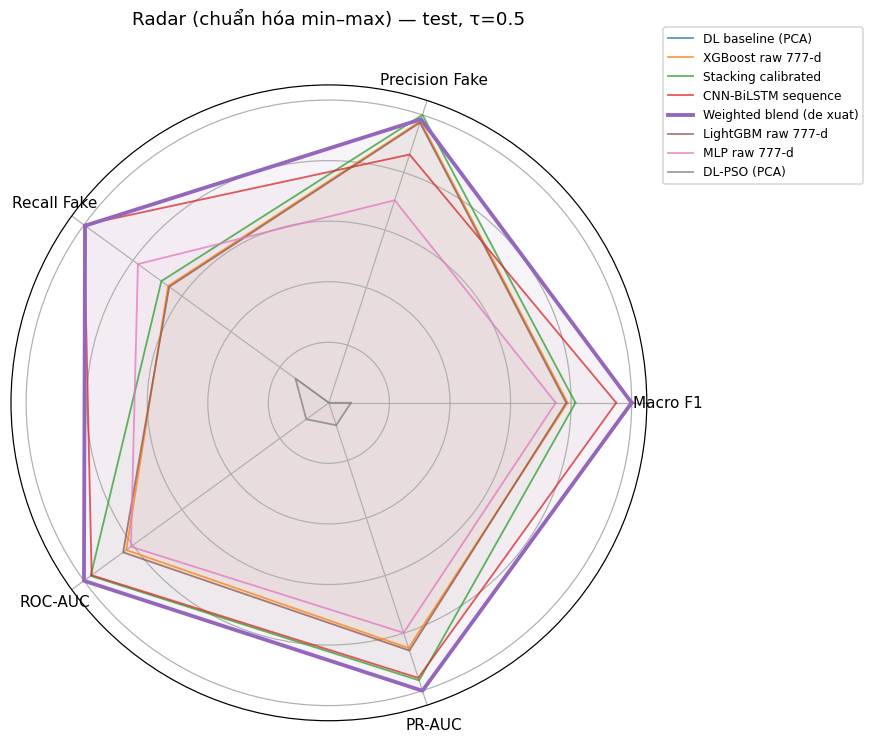

[HIỂN THỊ] viz_comparison_radar.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_radar.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_radar.png')

In [22]:
# ### VẼ BIỂU ĐỒ 3 — RADAR (trục từ viz_radar_metrics.csv)

radar_rows = df_radar_cfg[df_radar_cfg["radar_use"].astype(int) == 1].copy()
# radar_cols = ...: chuyển/chiếu thành list
radar_cols = radar_rows["metric_column"].tolist()
# radar_labels = ...: chuyển/chiếu thành list
radar_labels = radar_rows["ten_hien_thi"].tolist()

# raw = ...: ép kiểu dữ liệu cột
raw = df_compare.set_index("ten_hien_thi")[radar_cols].astype(float)

# Chuẩn hóa min-max theo từng cột trên tập model đang so sánh
norm = raw.copy()
# for: vòng lặp — for col in radar_cols:
for col in radar_cols:
    # vmin, vmax = norm[col].min(), norm[col].max(): lấy giá trị nhỏ nhất
    vmin, vmax = norm[col].min(), norm[col].max()
    # if: điều kiện — if vmax > vmin:
    if vmax > vmin:
        # norm[col] = (norm[col] - vmin) / (vmax - vmin): lấy giá trị nhỏ nhất
        norm[col] = (norm[col] - vmin) / (vmax - vmin)
    # else: nhánh còn lại của điều kiện
    else:
        # norm[col] = 1.0: thực thi lệnh Python
        norm[col] = 1.0

# angles = ...: chuyển/chiếu thành list
angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
# angles += angles[:1]: thực thi lệnh Python
angles += angles[:1]

# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True)): tạo dictionary
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# for: vòng lặp — for idx, (name, row) in enumerate(norm.iterrows()):
for idx, (name, row) in enumerate(norm.iterrows()):
    # vals = ...: chuyển/chiếu thành list
    vals = row.values.tolist()
    # vals += vals[:1]: thực thi lệnh Python
    vals += vals[:1]
    # highlight = ...: ép kiểu số nguyên
    highlight = int(df_compare.loc[df_compare["ten_hien_thi"] == name, "highlight"].iloc[0])
    # lw = ...: gán giá trị cho biến lw
    lw = 2.5 if highlight else 1.2
    # alpha = ...: gán giá trị cho biến alpha
    alpha = 1.0 if highlight else 0.75
    # ax.plot(angles, vals, linewidth=lw, alpha=alpha, label=name): thực thi lệnh Python
    ax.plot(angles, vals, linewidth=lw, alpha=alpha, label=name)
    # ax.fill(angles, vals, alpha=0.08 if highlight else 0.03): thực thi lệnh Python
    ax.fill(angles, vals, alpha=0.08 if highlight else 0.03)

# ax.set_xticks(angles[:-1]): tạo tập hợp
ax.set_xticks(angles[:-1])
# ax.set_xticklabels(radar_labels): tạo tập hợp
ax.set_xticklabels(radar_labels)
# ax.set_yticklabels([]): tạo tập hợp
ax.set_yticklabels([])
# ax.set_title(f"Radar (chuẩn hóa min–max) — test, τ={NGUONG_SO_SANH}", y=1.08): tạo tập hợp
ax.set_title(f"Radar (chuẩn hóa min–max) — test, τ={NGUONG_SO_SANH}", y=1.08)
# ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8): thực thi lệnh Python
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=8)
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_radar.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_radar.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [23]:
# ### INSIGHT — Biểu đồ 3: Radar (chuẩn hóa min–max)

radar_rows = df_radar_cfg[df_radar_cfg["radar_use"].astype(int) == 1]
# radar_cols = ...: chuyển/chiếu thành list
radar_cols = radar_rows["metric_column"].tolist()
# raw = ...: ép kiểu dữ liệu cột
raw = df_compare.set_index("ten_hien_thi")[radar_cols].astype(float)
# norm = ...: gán giá trị cho biến norm
norm = raw.copy()
# for: vòng lặp — for col in radar_cols:
for col in radar_cols:
    # vmin, vmax = norm[col].min(), norm[col].max(): lấy giá trị nhỏ nhất
    vmin, vmax = norm[col].min(), norm[col].max()
    # norm[col] = (norm[col] - vmin) / (vmax - vmin) if vmax > vmin else 1.0: lấy giá trị nhỏ nhất
    norm[col] = (norm[col] - vmin) / (vmax - vmin) if vmax > vmin else 1.0
# diem_tb = ...: tính trung bình
diem_tb = norm.mean(axis=1).sort_values(ascending=False)
# best_radar = ...: gán giá trị cho biến best radar
best_radar = diem_tb.index[0]
# blend_name = ...: ép kiểu dữ liệu cột
blend_name = df_compare[df_compare["highlight"].astype(int) == 1]["ten_hien_thi"].iloc[0]
# in_insight(: thực thi lệnh Python
in_insight(
    # 3,: thực thi lệnh Python
    3,
    # f"Sau chuẩn hóa min–max, điểm radar trung bình cao nhất: {best_radar} ({diem_tb....: lấy giá trị nhỏ nhất
    f"Sau chuẩn hóa min–max, điểm radar trung bình cao nhất: {best_radar} ({diem_tb.iloc[0]:.3f})",
    # "Radar so sánh hình dạng năng lực tương đối — không thay thế số tuyệt đối trong ...: thực thi lệnh Python
    "Radar so sánh hình dạng năng lực tương đối — không thay thế số tuyệt đối trong bảng Phase 7",
    # f"{blend_name}: điểm TB = {float(diem_tb.loc[blend_name]):.3f}",: ép kiểu số thực
    f"{blend_name}: điểm TB = {float(diem_tb.loc[blend_name]):.3f}",
# ): đóng ngoặc gọi hàm
)


[INSIGHT 3.1] Sau chuẩn hóa min–max, điểm radar trung bình cao nhất: Weighted blend (de xuat) (0.996)
[INSIGHT 3.2] Radar so sánh hình dạng năng lực tương đối — không thay thế số tuyệt đối trong bảng Phase 7
[INSIGHT 3.3] Weighted blend (de xuat): điểm TB = 0.996



## Biểu đồ 4 — Precision vs Recall (scatter, mỗi điểm = 1 model)

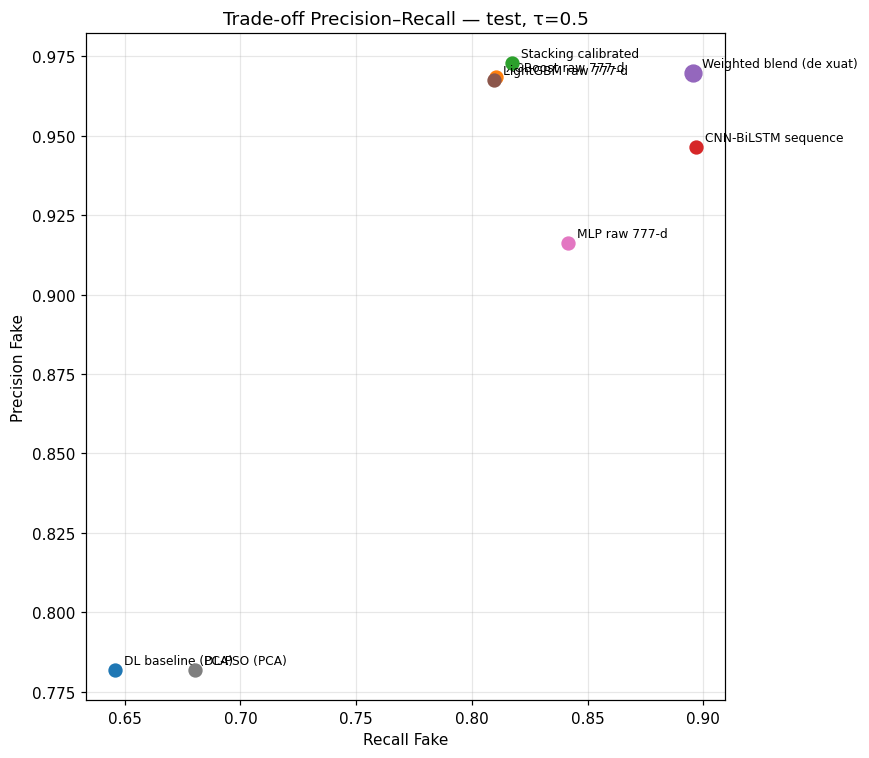

[HIỂN THỊ] viz_comparison_precision_recall_scatter.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_precision_recall_scatter.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_precision_recall_scatter.png')

In [24]:
# ### VẼ BIỂU ĐỒ 4 — SCATTER PRECISION–RECALL

fig, ax = plt.subplots(figsize=(8, 7))

# for: vòng lặp — for _, row in df_compare.iterrows():
for _, row in df_compare.iterrows():
    # prec = ...: ép kiểu số thực
    prec = float(row["precision_fake"])
    # rec = ...: ép kiểu số thực
    rec = float(row["recall_fake"])
    # highlight = ...: ép kiểu số nguyên
    highlight = int(row["highlight"]) == 1
    # ax.scatter(rec, prec, s=120 if highlight else 70, zorder=3,: thực thi lệnh Python
    ax.scatter(rec, prec, s=120 if highlight else 70, zorder=3,
               # label = ...: gán giá trị cho biến label
               label=row["ten_hien_thi"] if highlight else None)
    # ax.annotate(row["ten_hien_thi"], (rec, prec), textcoords="offset points", xytext...: tạo tập hợp
    ax.annotate(row["ten_hien_thi"], (rec, prec), textcoords="offset points", xytext=(6, 4), fontsize=8)

# ax.set_xlabel("Recall Fake"): tạo tập hợp
ax.set_xlabel("Recall Fake")
# ax.set_ylabel("Precision Fake"): tạo tập hợp
ax.set_ylabel("Precision Fake")
# ax.set_title(f"Trade-off Precision–Recall — test, τ={NGUONG_SO_SANH}"): tạo tập hợp
ax.set_title(f"Trade-off Precision–Recall — test, τ={NGUONG_SO_SANH}")
# ax.grid(True, alpha=0.3): thực thi lệnh Python
ax.grid(True, alpha=0.3)
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_precision_recall_scatter.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_precision_recall_scatter.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [25]:
# ### INSIGHT — Biểu đồ 4: Trade-off Precision–Recall

cao_prec = df_compare.loc[df_compare["precision_fake"].astype(float).idxmax()]
# cao_rec = ...: ép kiểu dữ liệu cột
cao_rec = df_compare.loc[df_compare["recall_fake"].astype(float).idxmax()]
# blend = ...: đếm số phần tử
blend = df_compare[df_compare["model_variant"] == "phase5_weighted_blend"].iloc[0]
# in_insight(: thực thi lệnh Python
in_insight(
    # 4,: thực thi lệnh Python
    4,
    # f"Precision Fake cao nhất: {cao_prec['ten_hien_thi']} = {float(cao_prec['precisi...: ép kiểu số thực
    f"Precision Fake cao nhất: {cao_prec['ten_hien_thi']} = {float(cao_prec['precision_fake']):.4f}",
    # f"Recall Fake cao nhất: {cao_rec['ten_hien_thi']} = {float(cao_rec['recall_fake'...: ép kiểu số thực
    f"Recall Fake cao nhất: {cao_rec['ten_hien_thi']} = {float(cao_rec['recall_fake']):.4f}",
    # f"Weighted blend nằm gần góc trên-phải: Prec={float(blend['precision_fake']):.4f...: ép kiểu số thực
    f"Weighted blend nằm gần góc trên-phải: Prec={float(blend['precision_fake']):.4f}, Rec={float(blend['recall_fake']):.4f}",
    # "Điểm gần (1,1) = cân bằng tốt; điểm lệch trái = bỏ sót fake nhiều hơn (FN cao)"...: thực thi lệnh Python
    "Điểm gần (1,1) = cân bằng tốt; điểm lệch trái = bỏ sót fake nhiều hơn (FN cao)",
# ): đóng ngoặc gọi hàm
)


[INSIGHT 4.1] Precision Fake cao nhất: Stacking calibrated = 0.9728
[INSIGHT 4.2] Recall Fake cao nhất: CNN-BiLSTM sequence = 0.8967
[INSIGHT 4.3] Weighted blend nằm gần góc trên-phải: Prec=0.9699, Rec=0.8956
[INSIGHT 4.4] Điểm gần (1,1) = cân bằng tốt; điểm lệch trái = bỏ sót fake nhiều hơn (FN cao)



## Biểu đồ 5 — Multi-seed: mean ± std (đọc phase7_multiseed_summary.csv)

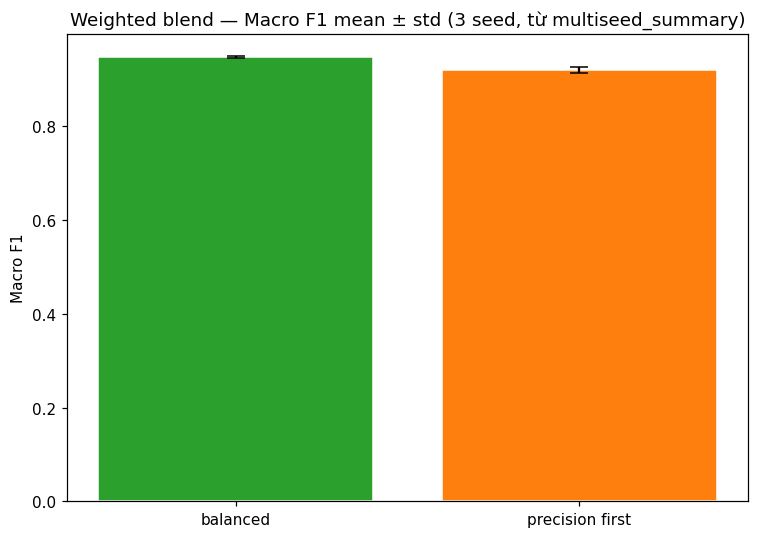

[HIỂN THỊ] viz_comparison_multiseed_macro_f1.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_multiseed_macro_f1.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_multiseed_macro_f1.png')

In [26]:
# ### VẼ BIỂU ĐỒ 5 — MULTI-SEED ERROR BAR

modes = df_multiseed["mode"].unique().tolist()
# metric_plot = ...: gán giá trị cho biến metric plot
metric_plot = "macro_f1"

# fig, ax = plt.subplots(figsize=(7, 5)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(7, 5))
# means, stds, labels_ms = [], [], []: tính trung bình
means, stds, labels_ms = [], [], []

# for: vòng lặp — for mode in modes:
for mode in modes:
    # row = ...: gán giá trị cho biến row
    row = df_multiseed[(df_multiseed["mode"] == mode) & (df_multiseed["metric"] == metric_plot)].iloc[0]
    # labels_ms.append(mode.replace("_", " ")): thực thi lệnh Python
    labels_ms.append(mode.replace("_", " "))
    # means.append(float(row["mean"])): ép kiểu số thực
    means.append(float(row["mean"]))
    # stds.append(float(row["std"])): ép kiểu số thực
    stds.append(float(row["std"]))

# x = ...: tạo dãy số cho vòng lặp
x = np.arange(len(labels_ms))
# ax.bar(x, means, yerr=stds, capsize=6, color=[": tính trung bình
ax.bar(x, means, yerr=stds, capsize=6, color=["#2ca02c", "#ff7f0e"], edgecolor="white")
# ax.set_xticks(x): tạo tập hợp
ax.set_xticks(x)
# ax.set_xticklabels(labels_ms): tạo tập hợp
ax.set_xticklabels(labels_ms)
# ax.set_ylabel("Macro F1"): tạo tập hợp
ax.set_ylabel("Macro F1")
# n_seeds = ...: ép kiểu số nguyên
n_seeds = int(df_multiseed["n_seeds"].iloc[0])
# ax.set_title(f"Weighted blend — Macro F1 mean ± std ({n_seeds} seed, từ multisee...: tính trung bình
ax.set_title(f"Weighted blend — Macro F1 mean ± std ({n_seeds} seed, từ multiseed_summary)")
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_multiseed_macro_f1.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_multiseed_macro_f1.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [27]:
# ### INSIGHT — Biểu đồ 5: Multi-seed ổn định

dong = []
# for: vòng lặp — for mode in df_multiseed["mode"].unique():
for mode in df_multiseed["mode"].unique():
    # row = ...: gán giá trị cho biến row
    row = df_multiseed[(df_multiseed["mode"] == mode) & (df_multiseed["metric"] == "macro_f1")].iloc[0]
    # dong.append(f"Chế độ {mode}: Macro F1 mean={float(row['mean']):.4f} ± std={float...: ép kiểu số thực
    dong.append(f"Chế độ {mode}: Macro F1 mean={float(row['mean']):.4f} ± std={float(row['std']):.4f} ({int(row['n_seeds'])} seed)")
# bal = ...: gán giá trị cho biến bal
bal = df_multiseed[(df_multiseed["mode"] == "balanced") & (df_multiseed["metric"] == "macro_f1")].iloc[0]
# pre = ...: gán giá trị cho biến pre
pre = df_multiseed[(df_multiseed["mode"] == "precision_first") & (df_multiseed["metric"] == "macro_f1")].iloc[0]
# dong.append(f"Balanced vượt precision_first về Macro F1: Δmean = {float(bal['mea...: ép kiểu số thực
dong.append(f"Balanced vượt precision_first về Macro F1: Δmean = {float(bal['mean']) - float(pre['mean']):.4f}")
# dong.append("Std nhỏ với balanced → kết quả ổn định qua nhiều seed, đáng tin cho...: thực thi lệnh Python
dong.append("Std nhỏ với balanced → kết quả ổn định qua nhiều seed, đáng tin cho báo cáo")
# in_insight(5, *dong): thực thi lệnh Python
in_insight(5, *dong)


[INSIGHT 5.1] Chế độ balanced: Macro F1 mean=0.9485 ± std=0.0018 (3 seed)
[INSIGHT 5.2] Chế độ precision_first: Macro F1 mean=0.9203 ± std=0.0066 (3 seed)
[INSIGHT 5.3] Balanced vượt precision_first về Macro F1: Δmean = 0.0282
[INSIGHT 5.4] Std nhỏ với balanced → kết quả ổn định qua nhiều seed, đáng tin cho báo cáo



## Biểu đồ 6 — Ablation: lợi ích ensemble (full − variant) từ phase7_ablation_delta.csv

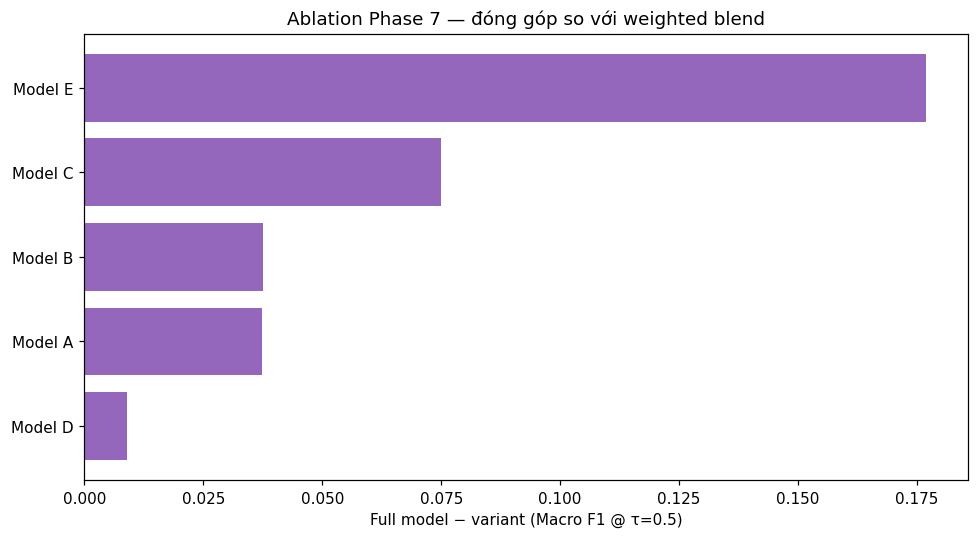

[HIỂN THỊ] viz_comparison_ablation_delta.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_ablation_delta.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_ablation_delta.png')

In [28]:
# ### VẼ BIỂU ĐỒ 6 — ABLATION DELTA MACRO F1

abl = df_ablation[df_ablation["ablation_variant"] != "Full Model"].copy()
# abl = ...: lấy giá trị nhỏ nhất
abl = abl.sort_values("full_minus_variant_macro_f1", ascending=True)

# fig, ax = plt.subplots(figsize=(9, 5)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(9, 5))
# ax.barh(abl["ablation_variant"], abl["full_minus_variant_macro_f1"].astype(float...: ép kiểu dữ liệu cột
ax.barh(abl["ablation_variant"], abl["full_minus_variant_macro_f1"].astype(float), color="#9467bd")
# ax.set_xlabel("Full model − variant (Macro F1 @ τ=0.5)"): xóa biến để giải phóng RAM/VRAM
ax.set_xlabel("Full model − variant (Macro F1 @ τ=0.5)")
# ax.set_title("Ablation Phase 7 — đóng góp so với weighted blend"): đếm số phần tử
ax.set_title("Ablation Phase 7 — đóng góp so với weighted blend")
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_ablation_delta.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_ablation_delta.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [29]:
# ### INSIGHT — Biểu đồ 6: Ablation — đóng góp từng nhánh

abl = df_ablation[df_ablation["ablation_variant"] != "Full Model"].copy()
# abl = ...: lấy giá trị nhỏ nhất
abl = abl.sort_values("full_minus_variant_macro_f1", ascending=False)
# dong = ...: gán giá trị cho biến dong
dong = [
    # f"{row['ablation_variant']}: bỏ nhánh → full hơn variant ΔMacro F1 = +{float(row...: ép kiểu số thực
    f"{row['ablation_variant']}: bỏ nhánh → full hơn variant ΔMacro F1 = +{float(row['full_minus_variant_macro_f1']):.4f}"
    # for: vòng lặp — for _, row in abl.iterrows()
    for _, row in abl.iterrows()
# ]: đóng khối danh sách
]
# lon_nhat = ...: gán giá trị cho biến lon nhat
lon_nhat = abl.iloc[0]
# dong.append(f"Đóng góp lớn nhất: {lon_nhat['ablation_variant']} (+{float(lon_nha...: ép kiểu số thực
dong.append(f"Đóng góp lớn nhất: {lon_nhat['ablation_variant']} (+{float(lon_nhat['full_minus_variant_macro_f1']):.4f})")
# dong.append("Model E (DL baseline) gap lớn → PSO+ensemble+feature engineering có...: xóa biến để giải phóng RAM/VRAM
dong.append("Model E (DL baseline) gap lớn → PSO+ensemble+feature engineering có vai trò then chốt so với DL đơn")
# in_insight(6, *dong): thực thi lệnh Python
in_insight(6, *dong)


[INSIGHT 6.1] Model E: bỏ nhánh → full hơn variant ΔMacro F1 = +0.1769
[INSIGHT 6.2] Model C: bỏ nhánh → full hơn variant ΔMacro F1 = +0.0749
[INSIGHT 6.3] Model B: bỏ nhánh → full hơn variant ΔMacro F1 = +0.0375
[INSIGHT 6.4] Model A: bỏ nhánh → full hơn variant ΔMacro F1 = +0.0374
[INSIGHT 6.5] Model D: bỏ nhánh → full hơn variant ΔMacro F1 = +0.0090
[INSIGHT 6.6] Đóng góp lớn nhất: Model E (+0.1769)
[INSIGHT 6.7] Model E (DL baseline) gap lớn → PSO+ensemble+feature engineering có vai trò then chốt so với DL đơn



## Biểu đồ 7 — Target audit: actual vs target (phase7_target_audit.csv)

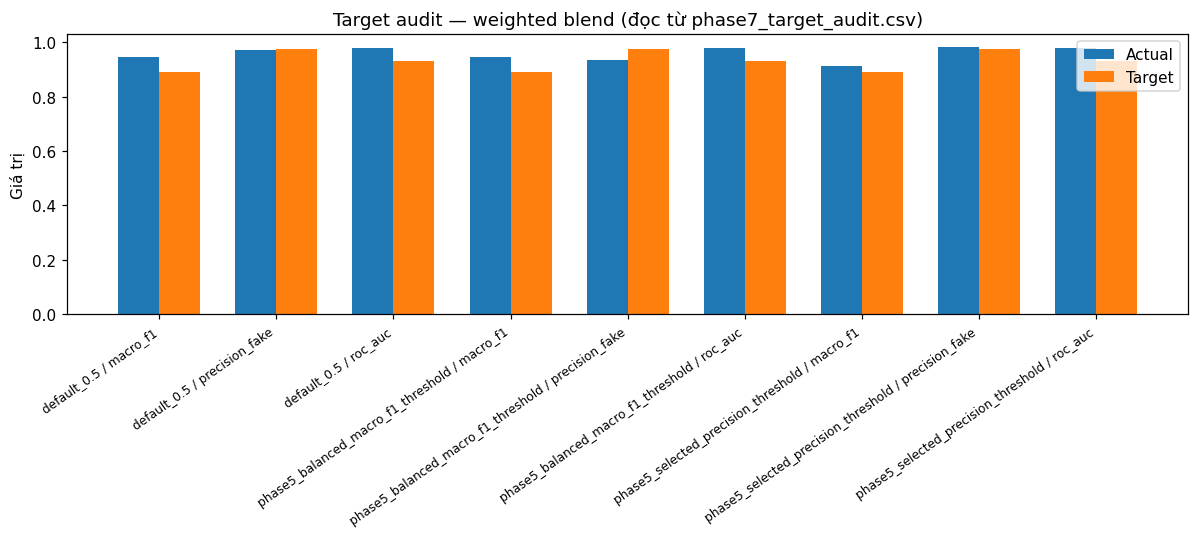

[HIỂN THỊ] viz_comparison_target_audit.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_target_audit.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_target_audit.png')

In [30]:
# ### VẼ BIỂU ĐỒ 7 — TARGET AUDIT GAP

audit = df_target.copy()
# audit["nhan"] = audit["threshold_strategy"].astype(str) + " / " + audit["metric"...: ép kiểu dữ liệu cột
audit["nhan"] = audit["threshold_strategy"].astype(str) + " / " + audit["metric"].astype(str)

# fig, ax = plt.subplots(figsize=(11, 5)): thực thi lệnh Python
fig, ax = plt.subplots(figsize=(11, 5))
# x = ...: tạo dãy số cho vòng lặp
x = np.arange(len(audit))
# width = ...: gán giá trị cho biến width
width = 0.35
# ax.bar(x - width / 2, audit["actual"].astype(float), width, label="Actual"): ép kiểu dữ liệu cột
ax.bar(x - width / 2, audit["actual"].astype(float), width, label="Actual")
# ax.bar(x + width / 2, audit["target"].astype(float), width, label="Target"): ép kiểu dữ liệu cột
ax.bar(x + width / 2, audit["target"].astype(float), width, label="Target")
# ax.set_xticks(x): tạo tập hợp
ax.set_xticks(x)
# ax.set_xticklabels(audit["nhan"], rotation=35, ha="right", fontsize=8): tạo tập hợp
ax.set_xticklabels(audit["nhan"], rotation=35, ha="right", fontsize=8)
# ax.set_ylabel("Giá trị"): tạo tập hợp
ax.set_ylabel("Giá trị")
# ax.set_title("Target audit — weighted blend (đọc từ phase7_target_audit.csv)"): đếm số phần tử
ax.set_title("Target audit — weighted blend (đọc từ phase7_target_audit.csv)")
# ax.legend(): thực thi lệnh Python
ax.legend()
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_target_audit.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_target_audit.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [31]:
# ### INSIGHT — Biểu đồ 7: Target audit

dong = []
# for: vòng lặp — for _, row in df_target.iterrows():
for _, row in df_target.iterrows():
    # trang_thai = ...: ép kiểu boolean
    trang_thai = "ĐẠT" if bool(row["pass"]) else "CHƯA ĐẠT"
    # dong.append(: thực thi lệnh Python
    dong.append(
        # f"τ={float(row['threshold']):.1f} | {row['threshold_strategy']} | {row['metric']...: ép kiểu số thực
        f"τ={float(row['threshold']):.1f} | {row['threshold_strategy']} | {row['metric']}: actual={float(row['actual']):.4f}, target={float(row['target']):.4f} → {trang_thai} (gap={float(row['gap_actual_minus_target']):+.4f})"
    # ): đóng ngoặc gọi hàm
    )
# dat = ...: ép kiểu dữ liệu cột
dat = df_target[df_target["pass"].astype(bool)]
# dong.append(f"Tổng: {len(dat)}/{len(df_target)} chỉ tiêu đạt; chưa đạt chủ yếu p...: đếm số phần tử
dong.append(f"Tổng: {len(dat)}/{len(df_target)} chỉ tiêu đạt; chưa đạt chủ yếu precision @ τ=0.5 và τ=0.3")
# dong.append("Precision-first @ τ=0.6 đạt precision_fake ≥ target → dùng khi ưu t...: thực thi lệnh Python
dong.append("Precision-first @ τ=0.6 đạt precision_fake ≥ target → dùng khi ưu tiên giảm báo động giả (FP)")
# in_insight(7, *dong): thực thi lệnh Python
in_insight(7, *dong)


[INSIGHT 7.1] τ=0.5 | default_0.5 | macro_f1: actual=0.9433, target=0.8900 → ĐẠT (gap=+0.0533)
[INSIGHT 7.2] τ=0.5 | default_0.5 | precision_fake: actual=0.9699, target=0.9750 → CHƯA ĐẠT (gap=-0.0051)
[INSIGHT 7.3] τ=0.5 | default_0.5 | roc_auc: actual=0.9769, target=0.9300 → ĐẠT (gap=+0.0469)
[INSIGHT 7.4] τ=0.3 | phase5_balanced_macro_f1_threshold | macro_f1: actual=0.9463, target=0.8900 → ĐẠT (gap=+0.0563)
[INSIGHT 7.5] τ=0.3 | phase5_balanced_macro_f1_threshold | precision_fake: actual=0.9344, target=0.9750 → CHƯA ĐẠT (gap=-0.0406)
[INSIGHT 7.6] τ=0.3 | phase5_balanced_macro_f1_threshold | roc_auc: actual=0.9769, target=0.9300 → ĐẠT (gap=+0.0469)
[INSIGHT 7.7] τ=0.6 | phase5_selected_precision_threshold | macro_f1: actual=0.9126, target=0.8900 → ĐẠT (gap=+0.0226)
[INSIGHT 7.8] τ=0.6 | phase5_selected_precision_threshold | precision_fake: actual=0.9816, target=0.9750 → ĐẠT (gap=+0.0066)
[INSIGHT 7.9] τ=0.6 | phase5_selected_precision_threshold | roc_auc: actual=0.9769, target=0.9300

## Biểu đồ 8 — Ma trận nhầm lẫn (TN/FP/FN/TP từ CSV, dual-threshold)

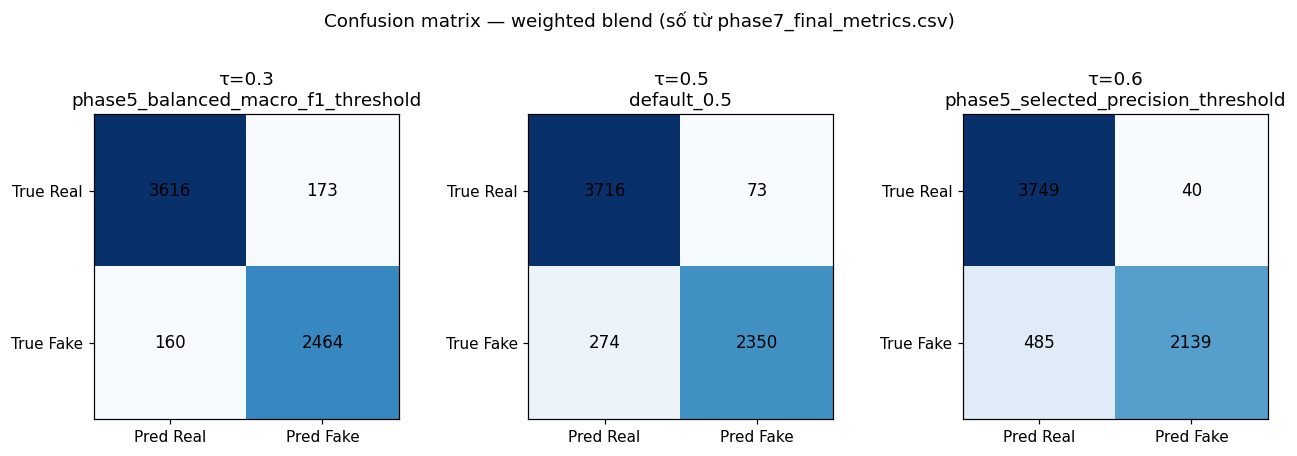

[HIỂN THỊ] viz_comparison_confusion_dual_threshold.png
[LƯU] C:\Users\vanhi\Desktop\HCMUTE_TMDT\HKII_Nam_3\Bao_Mat_TMDT\Fake_reviews\reports\figures\viz_comparison_confusion_dual_threshold.png


WindowsPath('C:/Users/vanhi/Desktop/HCMUTE_TMDT/HKII_Nam_3/Bao_Mat_TMDT/Fake_reviews/reports/figures/viz_comparison_confusion_dual_threshold.png')

In [32]:
# ### VẼ BIỂU ĐỒ 8 — CONFUSION HEATMAP (2 chế độ τ)

blend = df_metrics[
    # (df_metrics["model_variant"] == "phase5_weighted_blend"): đếm số phần tử
    (df_metrics["model_variant"] == "phase5_weighted_blend")
    # & (df_metrics["split"] == SPLIT): thực thi lệnh Python
    & (df_metrics["split"] == SPLIT)
    # & (df_metrics["seed"] == SEED): thực thi lệnh Python
    & (df_metrics["seed"] == SEED)
# ].copy(): thực thi lệnh Python
].copy()

# Lấy các chế độ ngưỡng từ target_audit (không hard-code τ)
thresholds = (
    # df_target[df_target["model_variant"] == "phase5_weighted_blend"][["threshold", "...: đếm số phần tử
    df_target[df_target["model_variant"] == "phase5_weighted_blend"][["threshold", "threshold_strategy"]]
    # .drop_duplicates(): thực thi lệnh Python
    .drop_duplicates()
    # .sort_values("threshold"): thực thi lệnh Python
    .sort_values("threshold")
# ): đóng ngoặc gọi hàm
)

# n_panels = ...: đếm số phần tử
n_panels = len(thresholds)
# fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4)): thực thi lệnh Python
fig, axes = plt.subplots(1, n_panels, figsize=(4 * n_panels, 4))
# if: điều kiện — if n_panels == 1:
if n_panels == 1:
    # axes = ...: gán giá trị cho biến axes
    axes = [axes]

# for: vòng lặp — for ax, (_, thr_row) in zip(axes, thresholds.iterrows()):
for ax, (_, thr_row) in zip(axes, thresholds.iterrows()):
    # thr = ...: ép kiểu số thực
    thr = float(thr_row["threshold"])
    # row = ...: ép kiểu dữ liệu cột
    row = blend[blend["threshold"].astype(float).round(2) == round(thr, 2)].iloc[0]
    # tn, fp, fn, tp = int(row["tn"]), int(row["fp"]), int(row["fn"]), int(row["tp"]): ép kiểu số nguyên
    tn, fp, fn, tp = int(row["tn"]), int(row["fp"]), int(row["fn"]), int(row["tp"])
    # cm = ...: gán giá trị cho biến cm
    cm = np.array([[tn, fp], [fn, tp]])
    # im = ...: gán giá trị cho biến im
    im = ax.imshow(cm, cmap="Blues")
    # ax.set_xticks([0, 1]): tạo tập hợp
    ax.set_xticks([0, 1])
    # ax.set_yticks([0, 1]): tạo tập hợp
    ax.set_yticks([0, 1])
    # ax.set_xticklabels(["Pred Real", "Pred Fake"]): tạo tập hợp
    ax.set_xticklabels(["Pred Real", "Pred Fake"])
    # ax.set_yticklabels(["True Real", "True Fake"]): tạo tập hợp
    ax.set_yticklabels(["True Real", "True Fake"])
    # for: vòng lặp — for (i, j), val in np.ndenumerate(cm):
    for (i, j), val in np.ndenumerate(cm):
        # ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=11): ép kiểu chuỗi
        ax.text(j, i, str(val), ha="center", va="center", color="black", fontsize=11)
    # ax.set_title(f"τ={thr}\n{thr_row['threshold_strategy']}"): tạo tập hợp
    ax.set_title(f"τ={thr}\n{thr_row['threshold_strategy']}")

# fig.suptitle("Confusion matrix — weighted blend (số từ phase7_final_metrics.csv)...: đếm số phần tử
fig.suptitle("Confusion matrix — weighted blend (số từ phase7_final_metrics.csv)", y=1.02)
# fig.tight_layout(): thực thi lệnh Python
fig.tight_layout()
# ve_luu_va_hien_thi(fig, "viz_comparison_confusion_dual_threshold.png"): thực thi lệnh Python
ve_luu_va_hien_thi(fig, "viz_comparison_confusion_dual_threshold.png")


### 💡 Insight (command) — đọc tự động từ CSV

In [33]:
# ### INSIGHT — Biểu đồ 8: Ma trận nhầm lẫn dual-threshold

thresholds = (
    # df_target[df_target["model_variant"] == "phase5_weighted_blend"][["threshold", "...: đếm số phần tử
    df_target[df_target["model_variant"] == "phase5_weighted_blend"][["threshold", "threshold_strategy"]]
    # .drop_duplicates(): thực thi lệnh Python
    .drop_duplicates()
    # .sort_values("threshold"): thực thi lệnh Python
    .sort_values("threshold")
# ): đóng ngoặc gọi hàm
)
# blend = ...: đếm số phần tử
blend = df_metrics[
    # (df_metrics["model_variant"] == "phase5_weighted_blend"): đếm số phần tử
    (df_metrics["model_variant"] == "phase5_weighted_blend")
    # & (df_metrics["split"] == SPLIT): thực thi lệnh Python
    & (df_metrics["split"] == SPLIT)
    # & (df_metrics["seed"] == SEED): thực thi lệnh Python
    & (df_metrics["seed"] == SEED)
# ]: đóng khối danh sách
]
# dong = ...: gán giá trị cho biến dong
dong = []
# for: vòng lặp — for _, thr_row in thresholds.iterrows():
for _, thr_row in thresholds.iterrows():
    # thr = ...: ép kiểu số thực
    thr = float(thr_row["threshold"])
    # row = ...: ép kiểu dữ liệu cột
    row = blend[blend["threshold"].astype(float).round(2) == round(thr, 2)].iloc[0]
    # tn, fp, fn, tp = int(row["tn"]), int(row["fp"]), int(row["fn"]), int(row["tp"]): ép kiểu số nguyên
    tn, fp, fn, tp = int(row["tn"]), int(row["fp"]), int(row["fn"]), int(row["tp"])
    # dong.append(f"τ={thr} ({thr_row['threshold_strategy']}): TN={tn}, FP={fp}, FN={f...: ép kiểu chuỗi
    dong.append(f"τ={thr} ({thr_row['threshold_strategy']}): TN={tn}, FP={fp}, FN={fn}, TP={tp} | FP+FN={fp + fn}")
# dong.append("FP = đánh fake nhầm review thật (báo động giả); FN = bỏ sót review ...: thực thi lệnh Python
dong.append("FP = đánh fake nhầm review thật (báo động giả); FN = bỏ sót review fake")
# dong.append("τ cao hơn (precision-first) thường giảm FP, có thể tăng FN — chọn τ...: thực thi lệnh Python
dong.append("τ cao hơn (precision-first) thường giảm FP, có thể tăng FN — chọn τ theo mục tiêu nghiệp vụ")
# in_insight(8, *dong): thực thi lệnh Python
in_insight(8, *dong)


[INSIGHT 8.1] τ=0.3 (phase5_balanced_macro_f1_threshold): TN=3616, FP=173, FN=160, TP=2464 | FP+FN=333
[INSIGHT 8.2] τ=0.5 (default_0.5): TN=3716, FP=73, FN=274, TP=2350 | FP+FN=347
[INSIGHT 8.3] τ=0.6 (phase5_selected_precision_threshold): TN=3749, FP=40, FN=485, TP=2139 | FP+FN=525
[INSIGHT 8.4] FP = đánh fake nhầm review thật (báo động giả); FN = bỏ sót review fake
[INSIGHT 8.5] τ cao hơn (precision-first) thường giảm FP, có thể tăng FN — chọn τ theo mục tiêu nghiệp vụ



## Tổng hợp insight cho báo cáo

In [34]:
# ### TỔNG HỢP INSIGHT — Kết luận cho báo cáo (đọc từ CSV)

best = df_compare.loc[df_compare["macro_f1"].astype(float).idxmax()]
# blend = ...: đếm số phần tử
blend = df_compare[df_compare["model_variant"] == "phase5_weighted_blend"].iloc[0]
# bal_ms = ...: gán giá trị cho biến bal ms
bal_ms = df_multiseed[(df_multiseed["mode"] == "balanced") & (df_multiseed["metric"] == "macro_f1")].iloc[0]

# print("=" * 60): in thông tin ra console
print("=" * 60)
# print("[TỔNG HỢP] KẾT LUẬN SO SÁNH MÔ HÌNH"): in thông tin ra console
print("[TỔNG HỢP] KẾT LUẬN SO SÁNH MÔ HÌNH")
# print("=" * 60): in thông tin ra console
print("=" * 60)
# in_insight(: thực thi lệnh Python
in_insight(
    # 9,: thực thi lệnh Python
    9,
    # f"So sánh {len(df_compare)} model @ test, seed={SEED}, τ={NGUONG_SO_SANH}",: xóa biến để giải phóng RAM/VRAM
    f"So sánh {len(df_compare)} model @ test, seed={SEED}, τ={NGUONG_SO_SANH}",
    # f"Headline: {best['ten_hien_thi']} đứng đầu Macro F1 = {float(best['macro_f1']):...: ép kiểu số thực
    f"Headline: {best['ten_hien_thi']} đứng đầu Macro F1 = {float(best['macro_f1']):.4f}",
    # f"Mô hình đề xuất weighted blend: Macro F1={float(blend['macro_f1']):.4f}, ROC-A...: ép kiểu số thực
    f"Mô hình đề xuất weighted blend: Macro F1={float(blend['macro_f1']):.4f}, ROC-AUC={float(blend['roc_auc']):.4f}",
    # f"Multi-seed balanced: {float(bal_ms['mean']):.4f} ± {float(bal_ms['std']):.4f} ...: ép kiểu số thực
    f"Multi-seed balanced: {float(bal_ms['mean']):.4f} ± {float(bal_ms['std']):.4f} → ổn định",
    # "Ablation: ensemble + feature engineering vượt DL baseline rõ rệt (xem [INSIGHT ...: thực thi lệnh Python
    "Ablation: ensemble + feature engineering vượt DL baseline rõ rệt (xem [INSIGHT 6])",
    # "Triển khai: dùng τ=0.3 (balanced) hoặc τ=0.6 (precision-first) tùy mức chấp nhậ...: thực thi lệnh Python
    "Triển khai: dùng τ=0.3 (balanced) hoặc τ=0.6 (precision-first) tùy mức chấp nhận FP/FN",
# ): đóng ngoặc gọi hàm
)
# print("[GỢI Ý BÁO CÁO] Copy các dòng [INSIGHT] phía trên vào slide/luận văn — số...: in thông tin ra console
print("[GỢI Ý BÁO CÁO] Copy các dòng [INSIGHT] phía trên vào slide/luận văn — số liệu luôn lấy từ file CSV.")


[TỔNG HỢP] KẾT LUẬN SO SÁNH MÔ HÌNH
[INSIGHT 9.1] So sánh 8 model @ test, seed=42, τ=0.5
[INSIGHT 9.2] Headline: Weighted blend (de xuat) đứng đầu Macro F1 = 0.9433
[INSIGHT 9.3] Mô hình đề xuất weighted blend: Macro F1=0.9433, ROC-AUC=0.9769
[INSIGHT 9.4] Multi-seed balanced: 0.9485 ± 0.0018 → ổn định
[INSIGHT 9.5] Ablation: ensemble + feature engineering vượt DL baseline rõ rệt (xem [INSIGHT 6])
[INSIGHT 9.6] Triển khai: dùng τ=0.3 (balanced) hoặc τ=0.6 (precision-first) tùy mức chấp nhận FP/FN

[GỢI Ý BÁO CÁO] Copy các dòng [INSIGHT] phía trên vào slide/luận văn — số liệu luôn lấy từ file CSV.


[HOÀN TẤT] Đã tạo 8 biểu đồ:
 - viz_comparison_ablation_delta.png
 - viz_comparison_confusion_dual_threshold.png
 - viz_comparison_grouped_metrics.png
 - viz_comparison_macro_f1_horizontal.png
 - viz_comparison_multiseed_macro_f1.png
 - viz_comparison_precision_recall_scatter.png
 - viz_comparison_radar.png
 - viz_comparison_target_audit.png

[GALLERY] Xem lại toàn bộ biểu đồ ngay trong notebook:

--- viz_comparison_ablation_delta.png ---


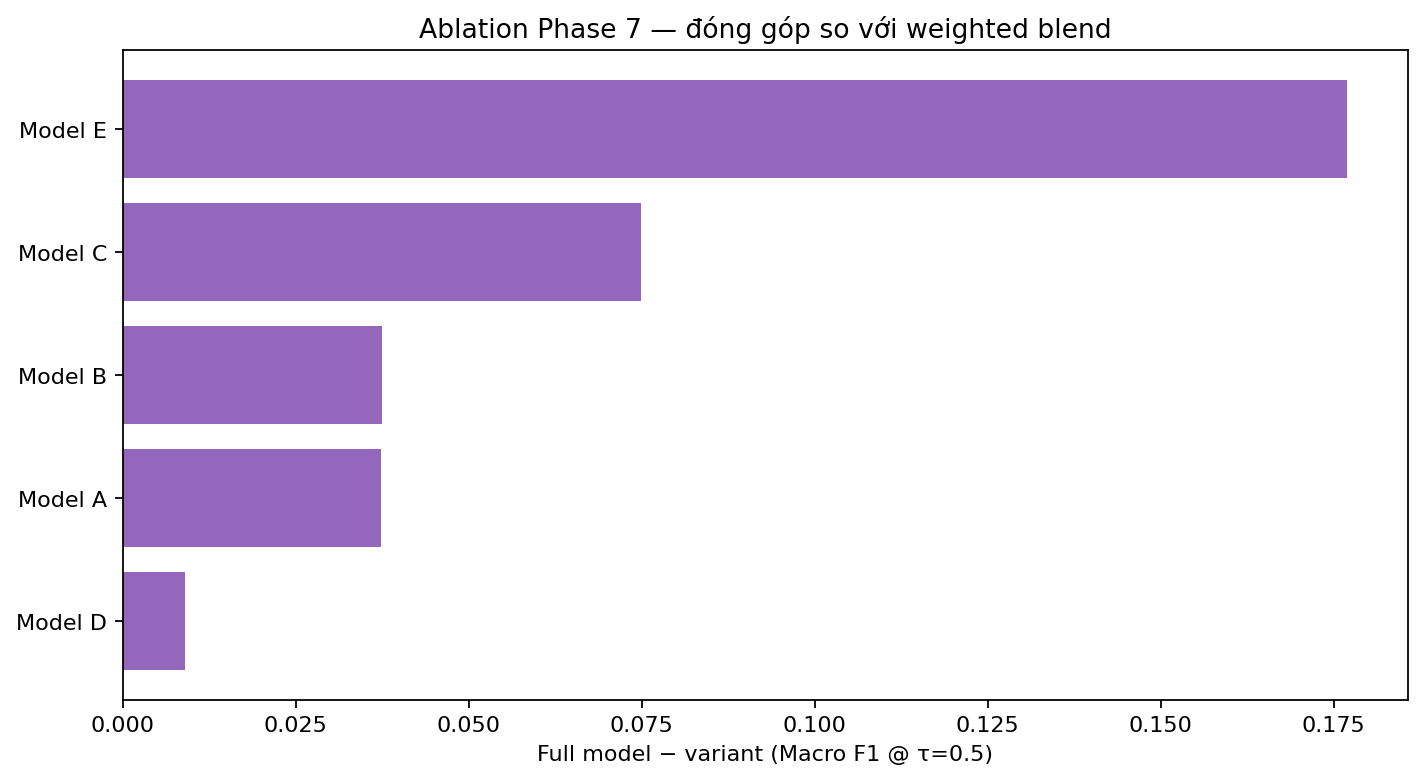


--- viz_comparison_confusion_dual_threshold.png ---


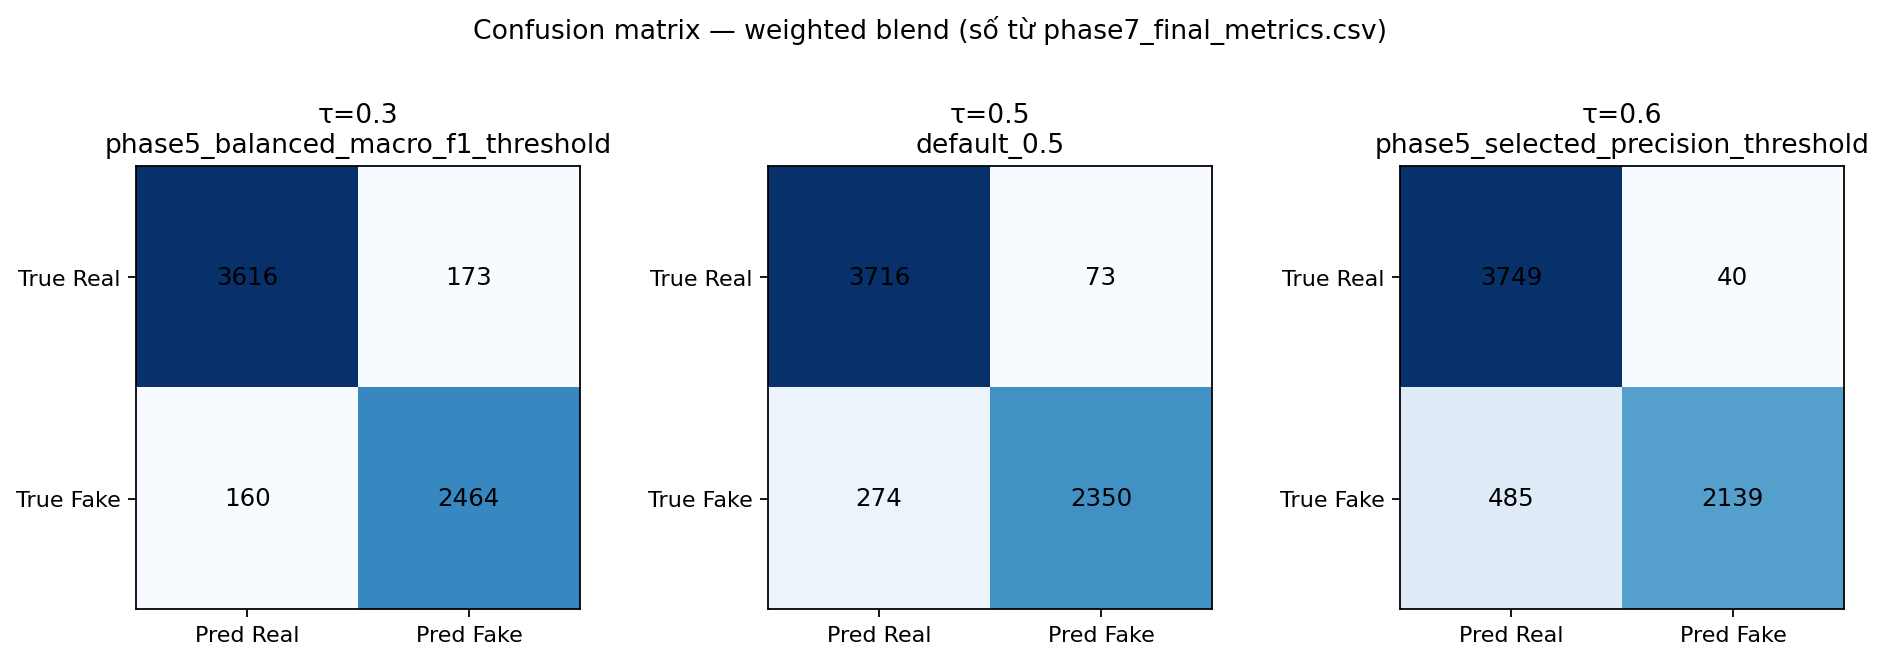


--- viz_comparison_grouped_metrics.png ---


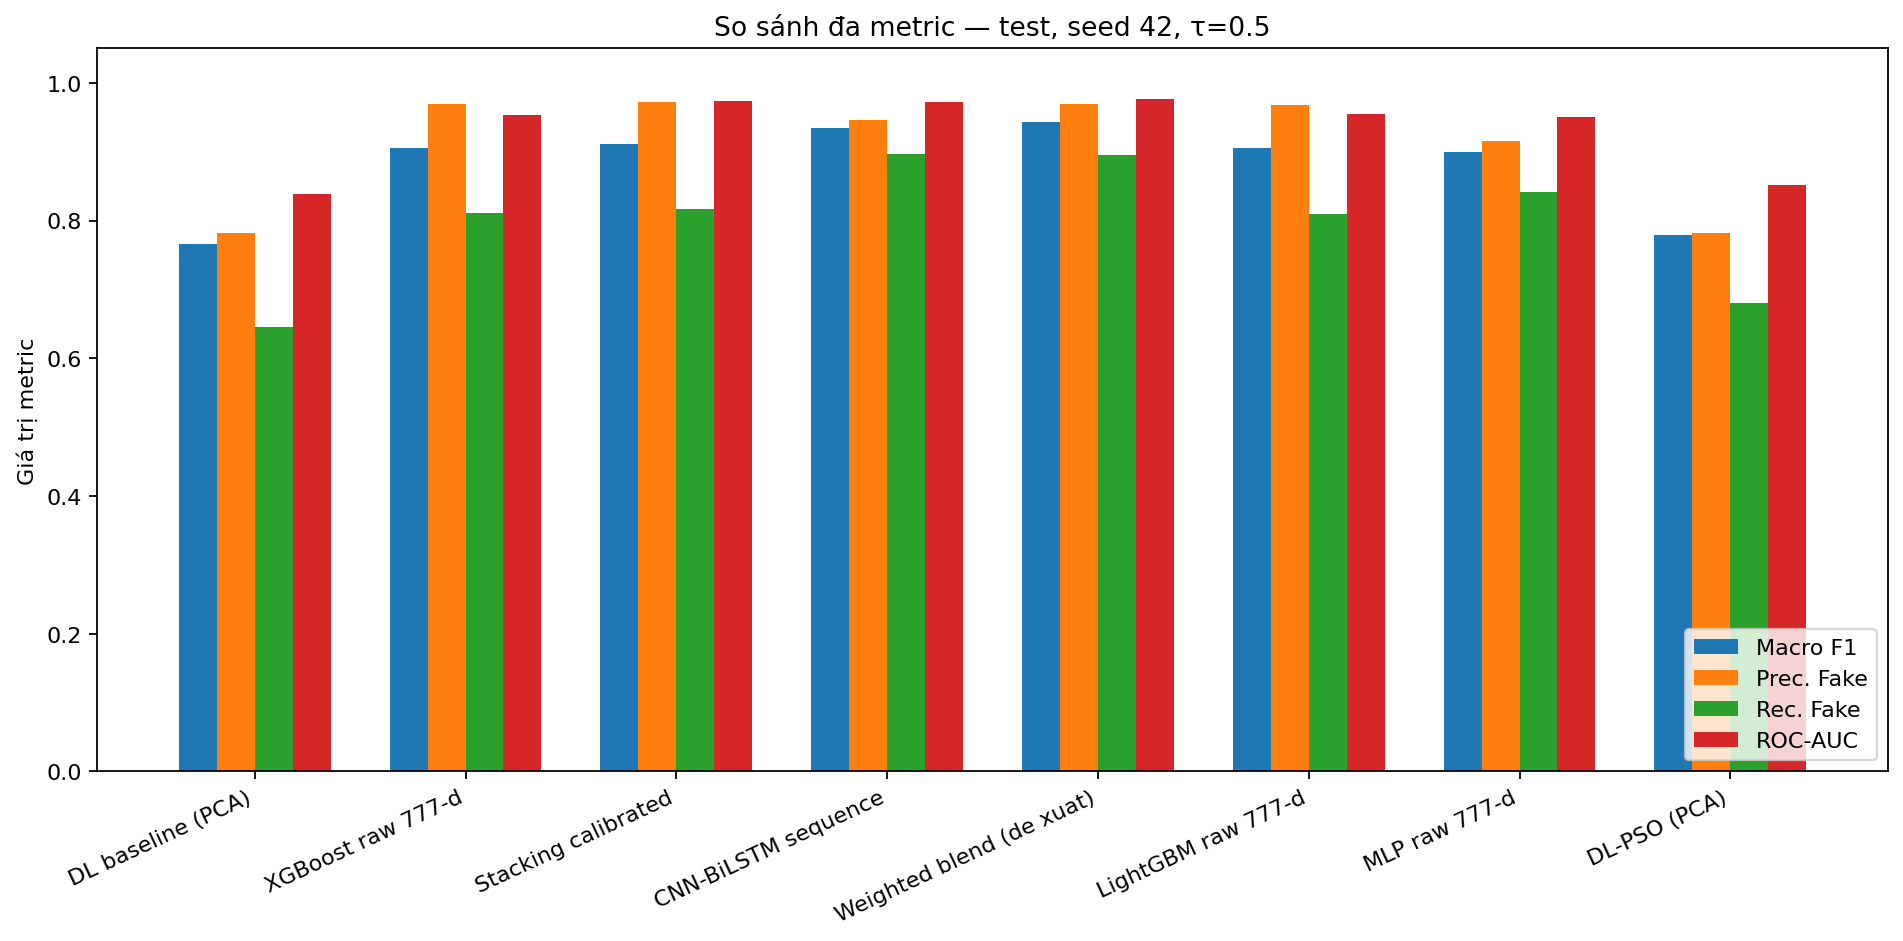


--- viz_comparison_macro_f1_horizontal.png ---


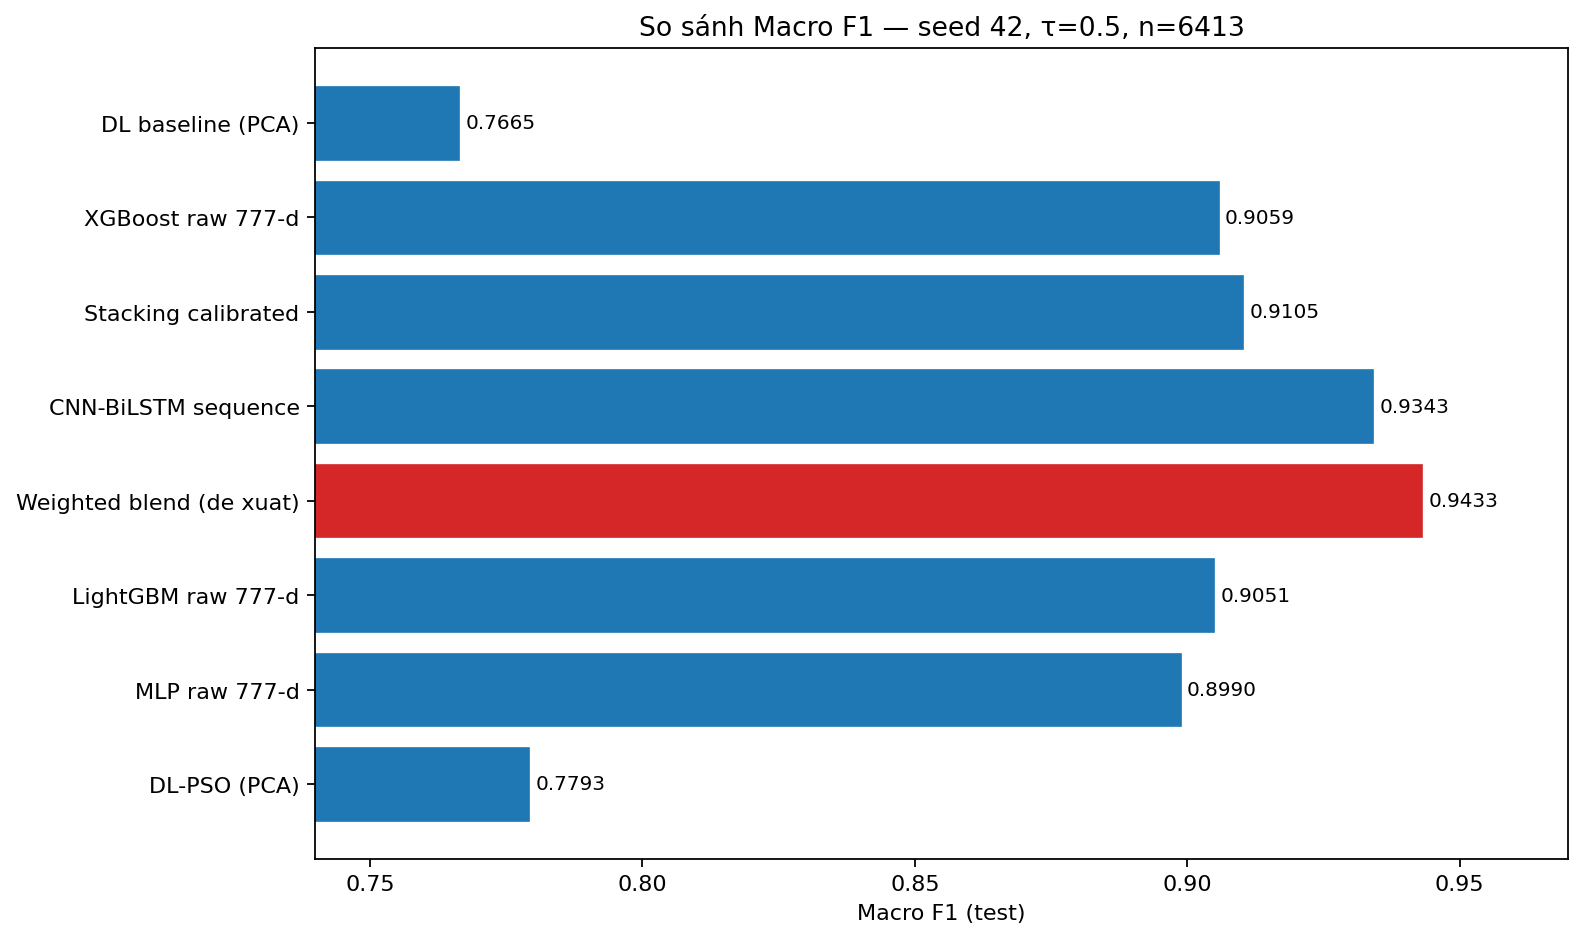


--- viz_comparison_multiseed_macro_f1.png ---


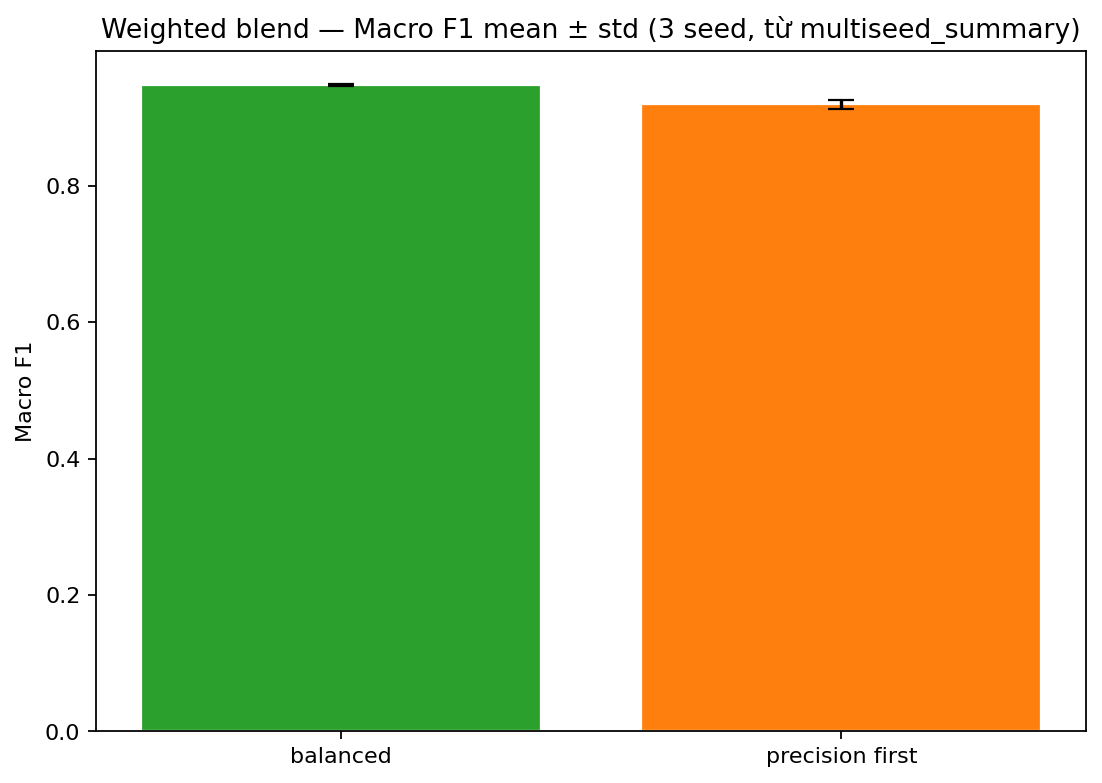


--- viz_comparison_precision_recall_scatter.png ---


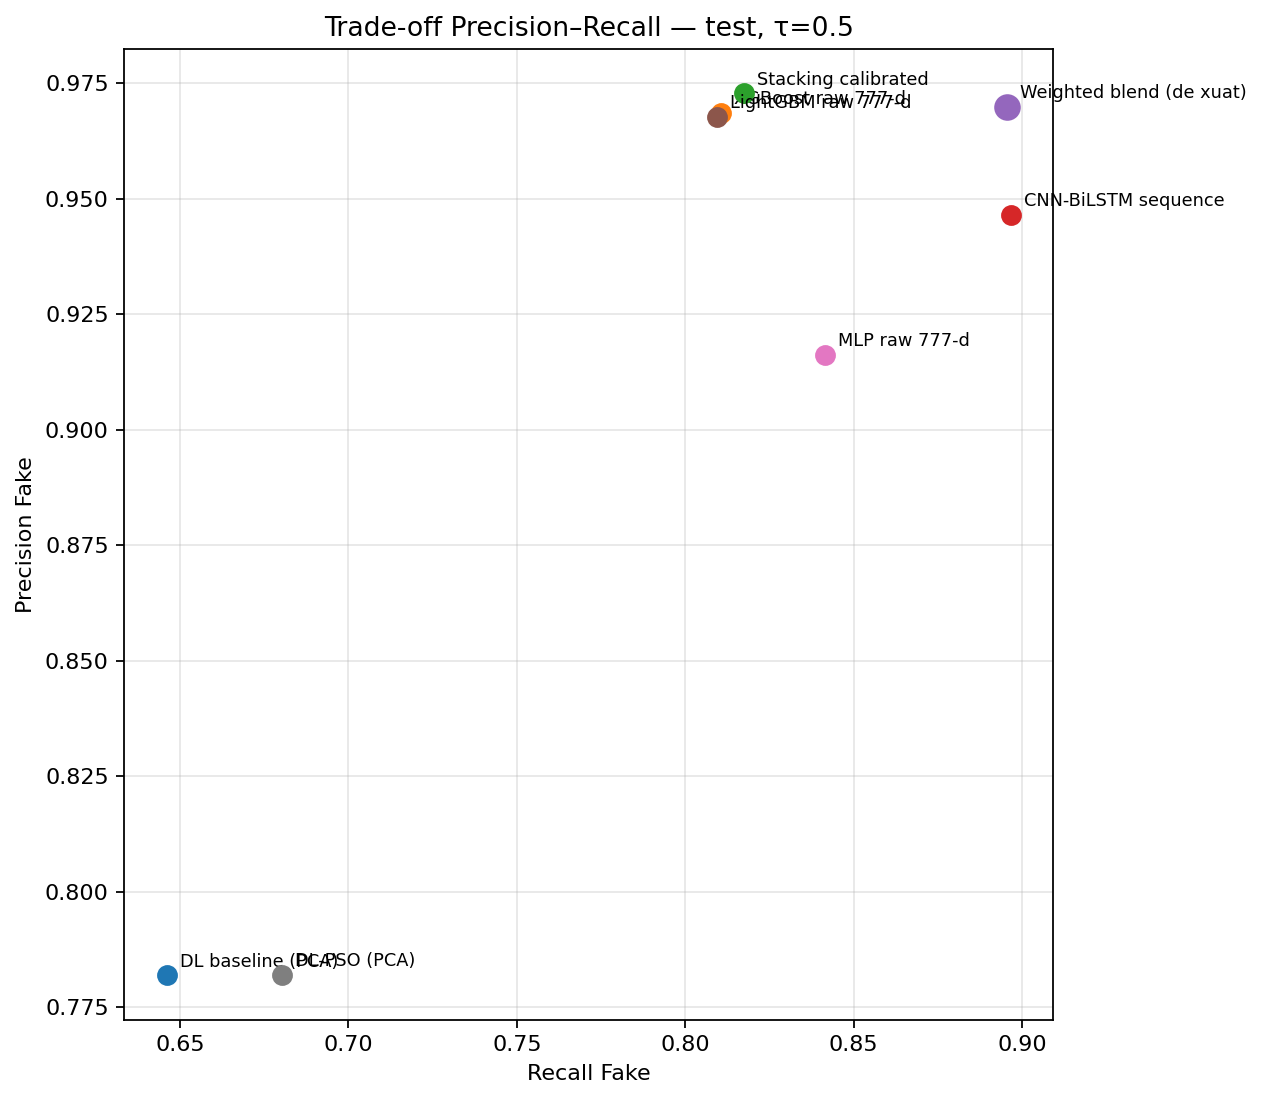


--- viz_comparison_radar.png ---


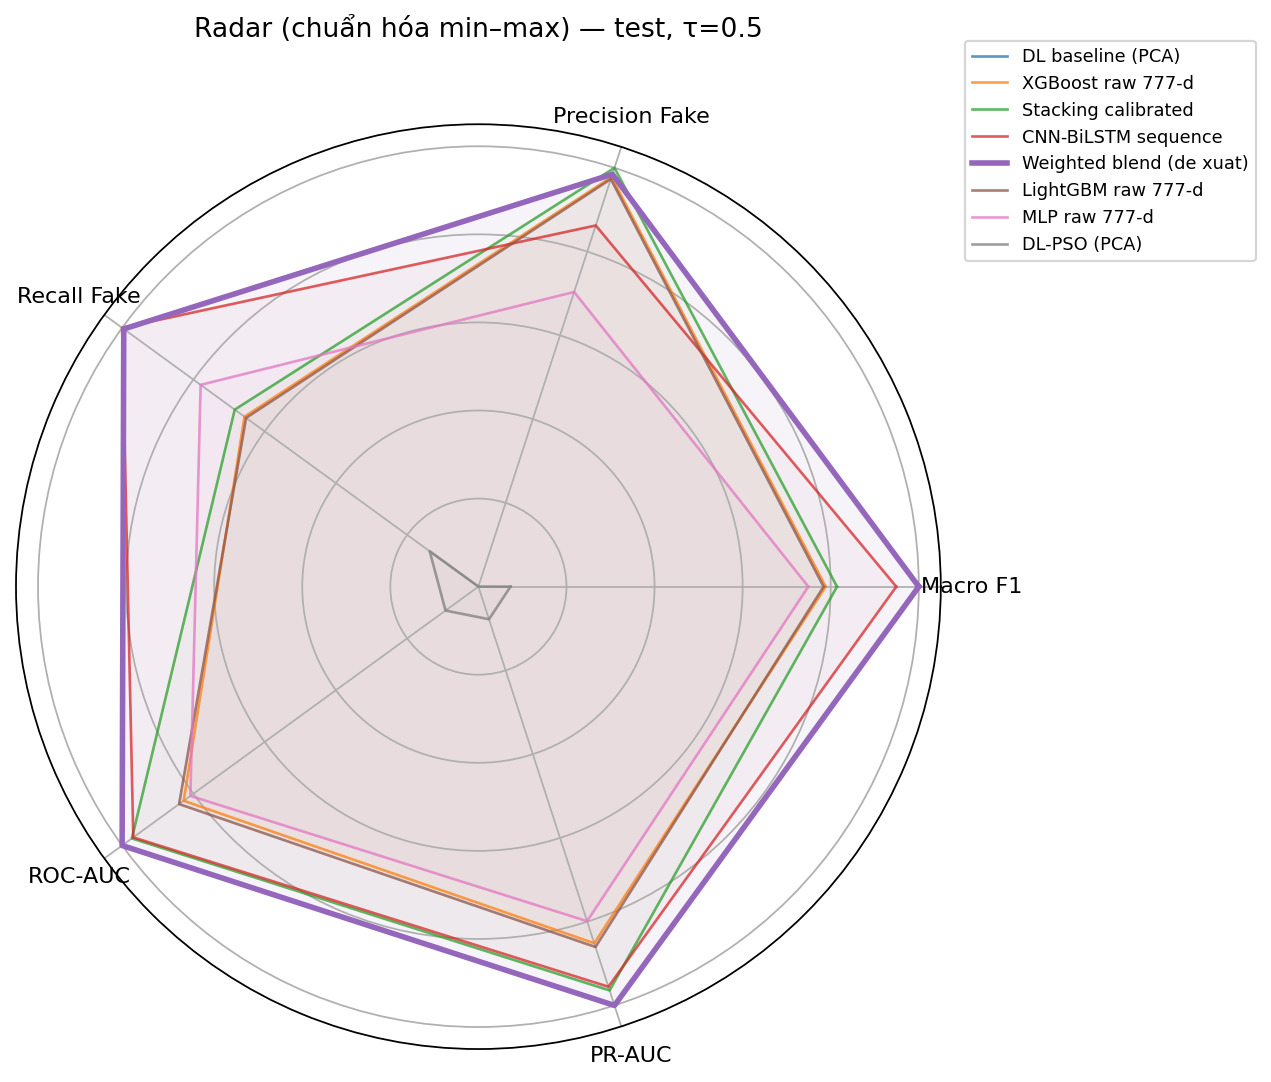


--- viz_comparison_target_audit.png ---


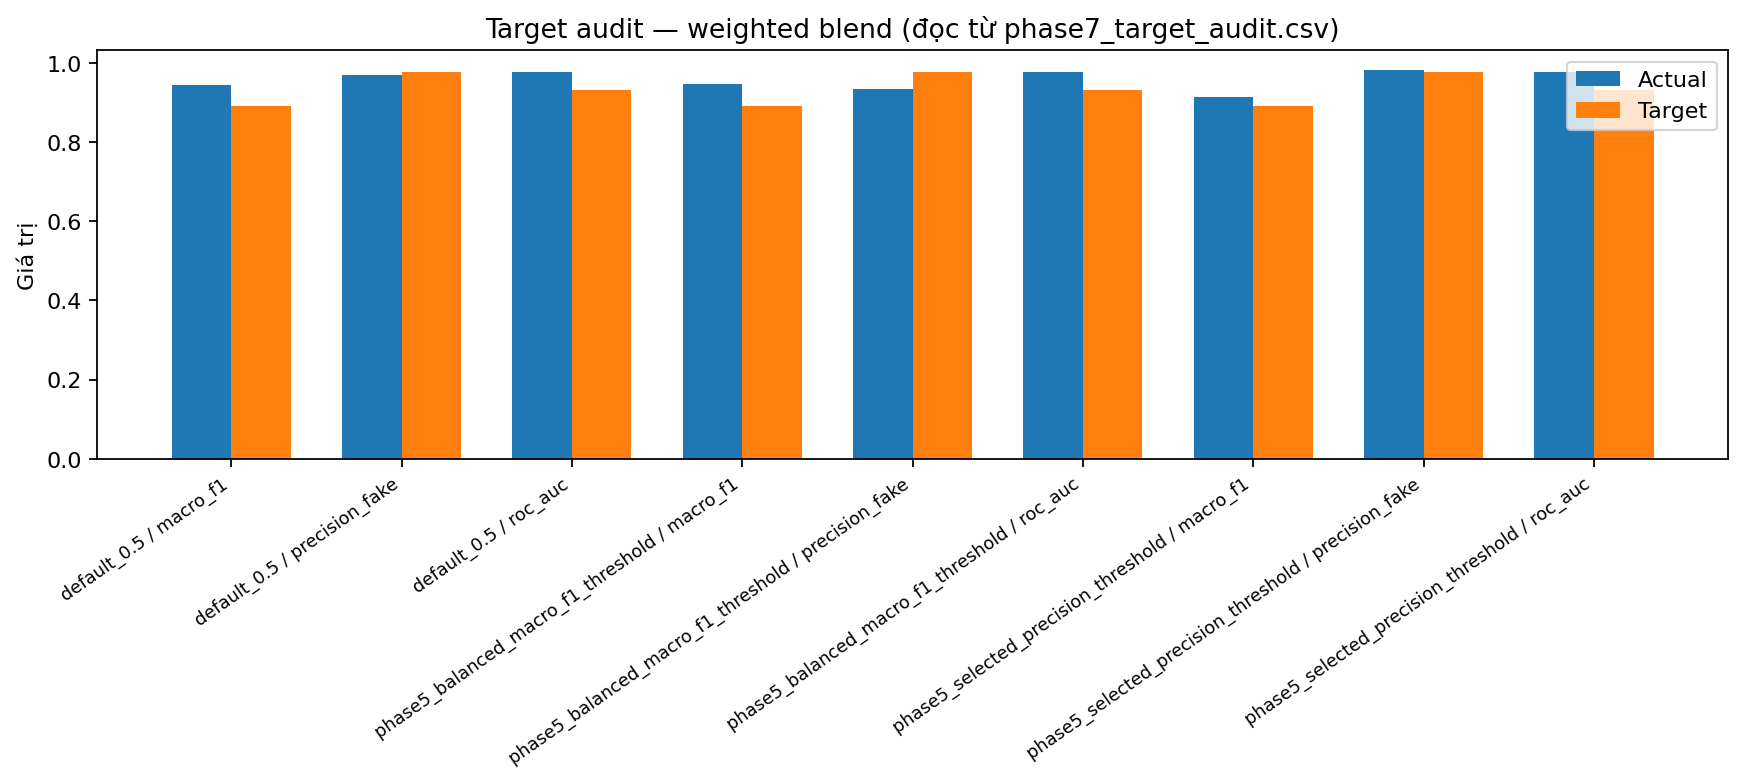


[GỢI Ý] Chỉnh danh sách model: sửa reports/tables/viz_comparison_models.csv rồi chạy lại notebook.


In [35]:
# ### BƯỚC CUỐI — TỔNG KẾT + XEM LẠI TẤT CẢ BIỂU ĐỒ TRONG NOTEBOOK

from IPython.display import Image, display

# files = ...: sắp xếp danh sách
files = sorted(FIGURE_DIR.glob("viz_comparison_*.png"))
# print("[HOÀN TẤT] Đã tạo", len(files), "biểu đồ:"): in thông tin ra console
print("[HOÀN TẤT] Đã tạo", len(files), "biểu đồ:")
# for: vòng lặp — for f in files:
for f in files:
    # print(" -", f.name): in thông tin ra console
    print(" -", f.name)

# print("\n[GALLERY] Xem lại toàn bộ biểu đồ ngay trong notebook:"): in thông tin ra console
print("\n[GALLERY] Xem lại toàn bộ biểu đồ ngay trong notebook:")
# for: vòng lặp — for f in files:
for f in files:
    # print(f"\n--- {f.name} ---"): in thông tin ra console
    print(f"\n--- {f.name} ---")
    # display(Image(filename=str(f))): hiển thị bảng/kết quả trên notebook
    display(Image(filename=str(f)))

# print("\n[GỢI Ý] Chỉnh danh sách model: sửa reports/tables/viz_comparison_models...: in thông tin ra console
print("\n[GỢI Ý] Chỉnh danh sách model: sửa reports/tables/viz_comparison_models.csv rồi chạy lại notebook.")
